In [1]:
#other imports
import os
import sys
import numpy as np
#os.chdir('C:/Code/Github/GLM_python-main')
project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# Import path setup
from utils.path_utils import setup_paths
base_dir = setup_paths()

In [3]:
# Helper functions
from helper_functions.data_trial_plotter import TrialPlotter
from helper_functions.data_trial_divider import TrialDivider

# Core modules
from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from utils.Plotter import Plotter as plotterfun

from analysis.DecoderAnalyzer import DecoderAnalyzer as analysisdec
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun


# from analysis_code.DataHandlerEncoding import DataHandlerEncoding as datafun
# from analysis_code.Plotter import Plotter as plotterfun
# from analysis_code.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun

In [4]:
#initialize class
data_handler = datafun(data=None)  # Pass any initial data if needed

In [5]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
for dat in datasets:
    print(dat)

# # Indices to remove (example: remove datasets at indices 0 and 2)
# remove_indices = range(2,25) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]

# # Remove indices from both lists
# datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
# mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]

# # Print remaining datasets
# for dat in datasets:
#     print(f'{dat} loaded')

('HA11-1R', '2023-05-05', 'V:')
('HA11-1R', '2023-04-13', 'V:')
('HA2-1L', '2023-04-12', 'V:')
('HA2-1L', '2023-05-05', 'V:')
('HA1-00', '2023-06-29', 'V:')
('HA1-00', '2023-08-28', 'W:')
('HE4-1L1R', '2023-08-21', 'W:')
('HE4-1L1R', '2023-08-24', 'W:')
('HA10-1L', '2023-04-10', 'V:')
('HA10-1L', '2023-04-17', 'V:')
('HA10-1L', '2023-04-12', 'V:')
('HA11-1R', '2023-04-07', 'V:')
('HA11-1R', '2023-05-01', 'V:')
('HA11-1R', '2023-05-02', 'V:')
('HA2-1L', '2023-04-28', 'V:')
('HA2-1L', '2023-05-01', 'V:')
('HA1-00', '2023-06-27', 'V:')
('HA1-00', '2023-07-07', 'W:')
('HA1-00', '2023-08-25', 'W:')
('HE4-1L1R', '2023-08-14', 'W:')
('HE4-1L1R', '2023-08-28', 'W:')
('HE4-1L1R', '2023-09-04', 'W:')
('HE4-1L1R', '2023-09-11', 'W:')
('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')


In [6]:
#LOAD ACTUAL DATASETS (CAN TAKE A WHILE ~50MIN)
save_results = os.path.join(f'W:\Connie/results\Bassi2025\glm_coupling') # os.path.join(f'V:/Connie/results/glm/all_together/updated')
os.makedirs(save_results, exist_ok=True)

model_type = 'GLM_3nmf_pre'
results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated')
model_type = 'GLM_3nmf_iti'
results_iti = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated')
model_type = 'GLM_3nmf_passive'
results_pass = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated')

Processing dataset: HA11-1R_2023-05-05
poss_model_1_data_cluster_0.pkl
poss_model_1_data_cluster_1.pkl
poss_model_1_data_cluster_2.pkl
poss_model_1_data_cluster_3.pkl
poss_model_1_data_cluster_4.pkl
poss_model_1_data_cluster_5.pkl
poss_model_1_data_cluster_6.pkl
poss_model_1_data_cluster_7.pkl
poss_model_1_data_cluster_8.pkl
poss_model_1_data_cluster_9.pkl
poss_model_1_data_cluster_10.pkl
poss_model_1_data_cluster_11.pkl
poss_model_1_data_cluster_12.pkl
poss_model_1_data_cluster_13.pkl
poss_model_1_data_cluster_14.pkl
poss_model_1_data_cluster_15.pkl
poss_model_1_data_cluster_16.pkl
poss_model_1_data_cluster_17.pkl
poss_model_1_data_cluster_18.pkl
poss_model_1_data_cluster_19.pkl
poss_model_1_data_cluster_20.pkl
poss_model_1_data_cluster_21.pkl
poss_model_1_data_cluster_22.pkl
poss_model_1_data_cluster_23.pkl
poss_model_1_data_cluster_24.pkl
poss_model_1_data_cluster_25.pkl
poss_model_1_data_cluster_26.pkl
poss_model_1_data_cluster_27.pkl
poss_model_1_data_cluster_28.pkl
poss_model_1_d

In [7]:
save_results = os.path.join(f'W:\Connie/results\Bassi2025\glm_coupling')#'V:/Connie/results/glm/all_2024')
os.makedirs(save_results, exist_ok=True)

results_pre = data_handler.load_pkls(save_results, "pre") #8min
results_iti = data_handler.load_pkls(save_results, "iti") #3min
results_pass = data_handler.load_pkls(save_results, "pass") #2 #5min

# model_type = 'GLM_3nmf_pre'
# results_pre = data_handler.process_multiple_datasets([('HA11-1R', '2023-05-05', 'V:')], model_type)
# # model_type = 'GLM_3nmf_iti'
# # results_iti = data_handler.process_multiple_datasets([('HA11-1R', '2023-05-05', 'V:')], model_type)
# model_type = 'GLM_3nmf_passive'
# results_pass = data_handler.process_multiple_datasets([('HA11-1R', '2023-05-05', 'V:')], model_type)


Loaded file: results_pre.pkl
Loaded file: results_iti.pkl
Loaded file: results_passive.pkl


In [6]:
save_results = f'W:\Connie/results\Bassi2025\glm_coupling' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)

In [8]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)


HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
HA10-1L_2023-03-31
HE1-00_2023-05-30


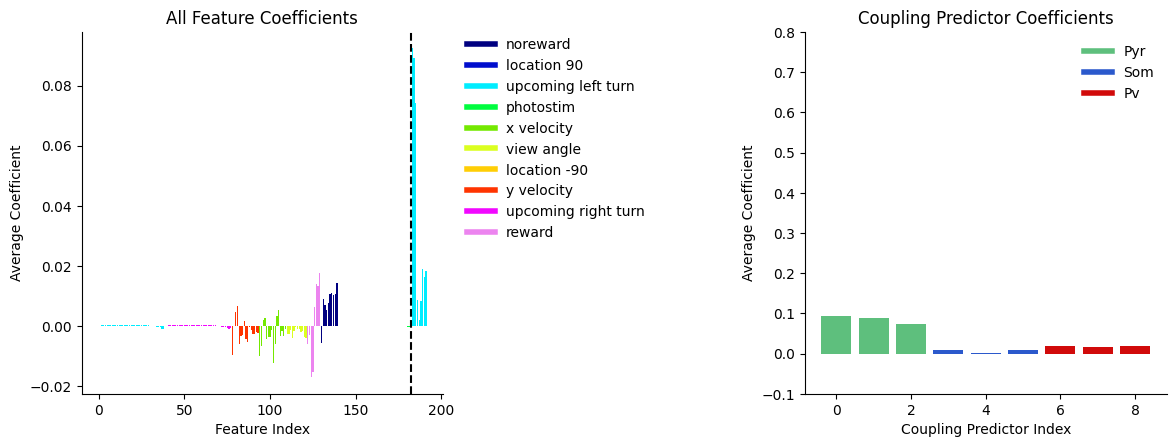

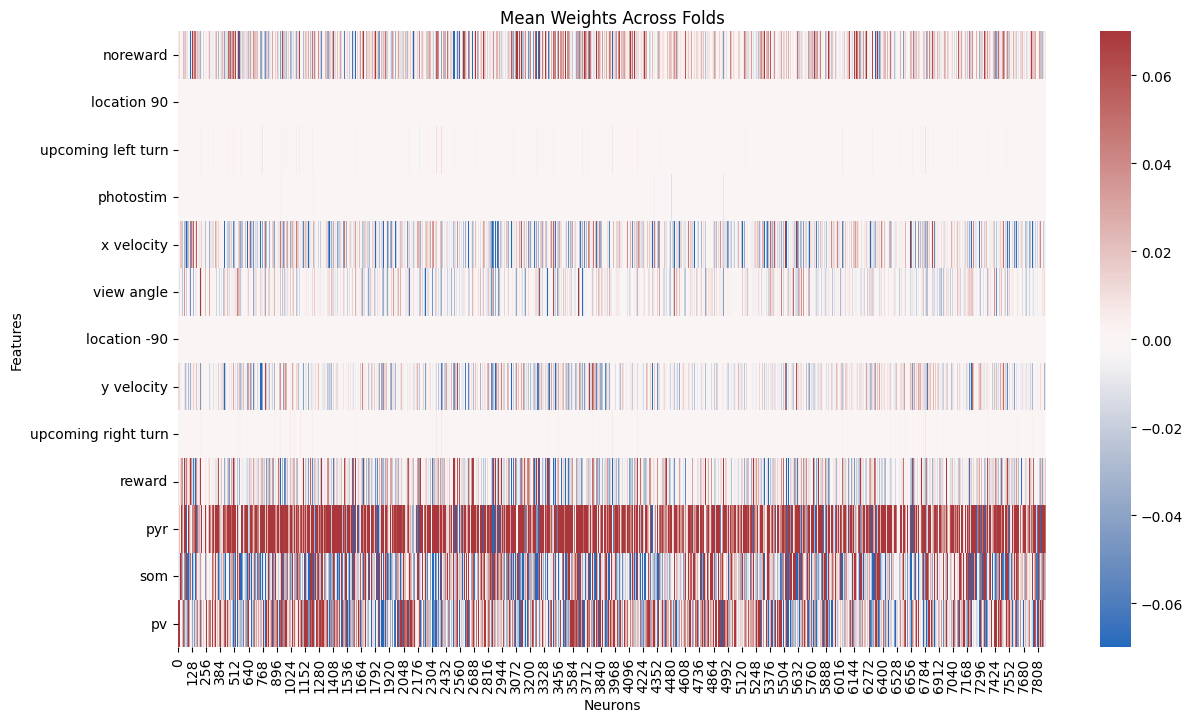

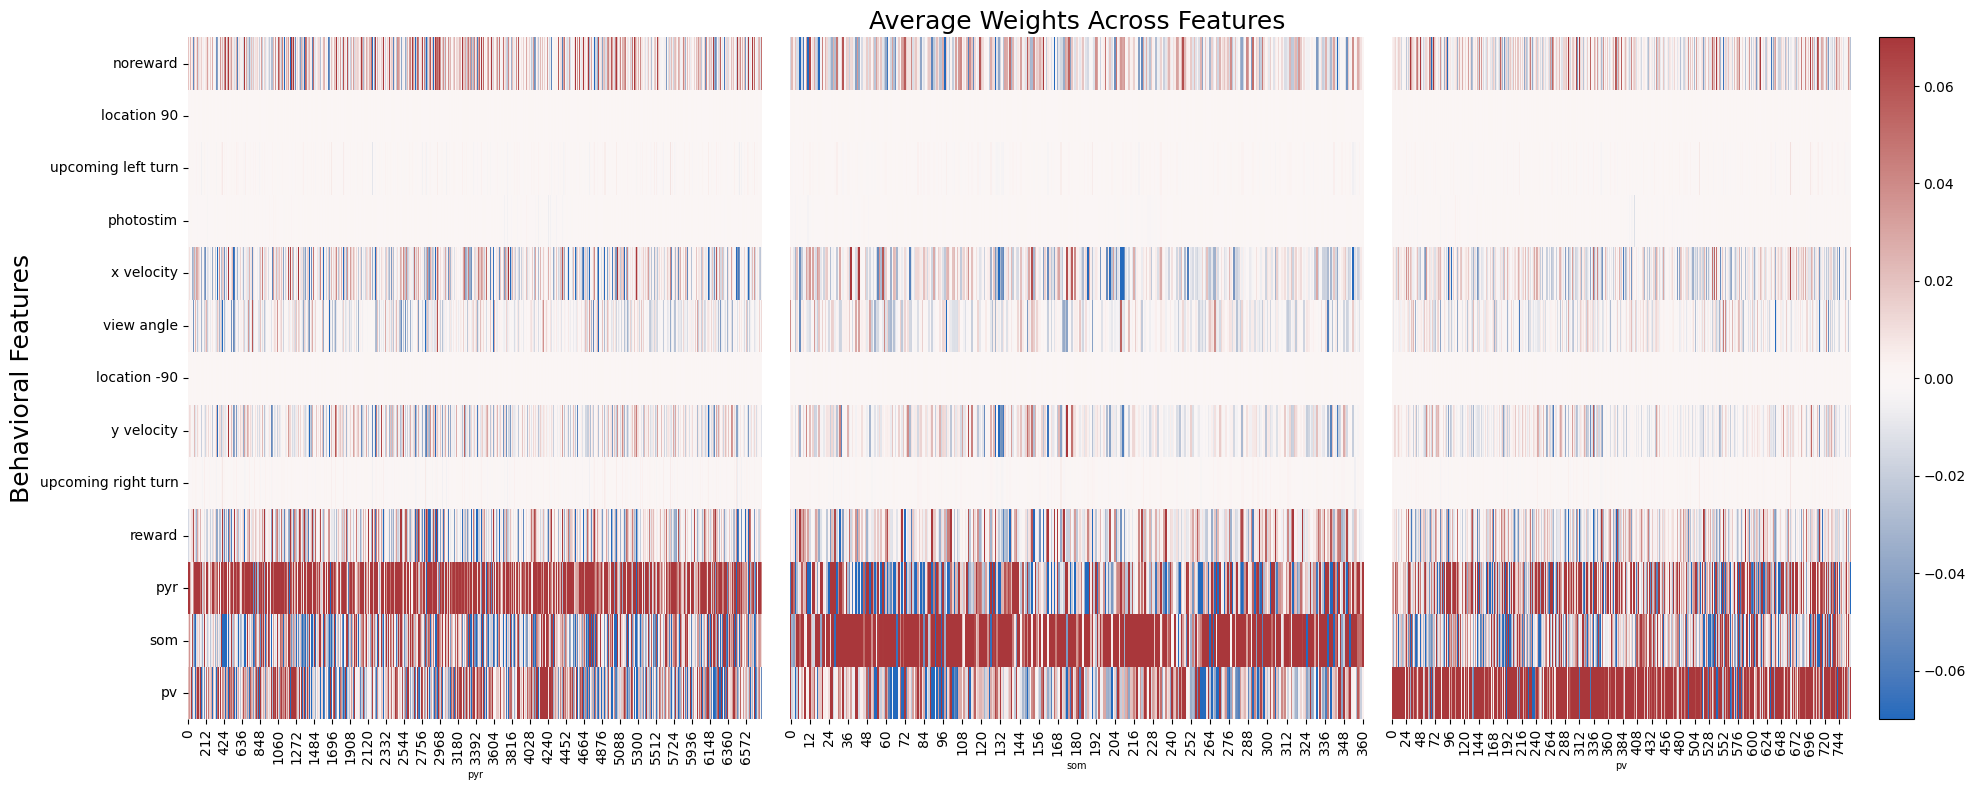

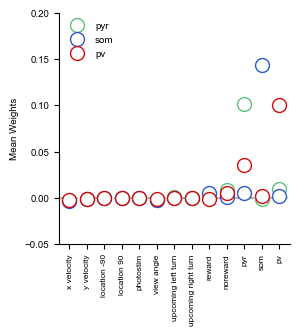

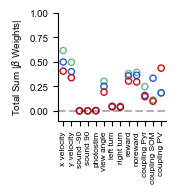

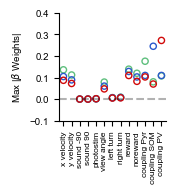

In [9]:
#PLOT EXAMPLE RESULT PREDICTORS!
server = 'V:'
animalID = 'HA11-1R'
date = '2023-05-05'
results = results_iti
celltypecolors = results[f'{animalID}_{date}']['colors']
model_types = 'GLM_3nmf_iti'  # List your model types / COMBINED
no_abs = 1
minmaxlims= (-0.07,0.07)

#Aggregate chosen model
combined_output = data_handler.combine_model_output_all(results) #currently just doing model output all

# Aggregate model data
combined_B_weights, feature_names, other_weights, coupling_weights, coupling_indices,celltype_array, neuron_groups, start_indices = data_handler.aggregate_model_data_from_results(results, no_abs)

# Now use the aggregated data for plotting
plotter.plot_feature_weights(server=server, animalID=animalID, date=date, model_type=model_types, 
                     model_chosen=combined_output, no_abs=no_abs)

mean_neuron_feature_unique,unique_feature_names,mean_weights,feature_names,total_beta_feature_unique,max_beta_feature_unique = plotter.plot_weights_heatmap(server=server, animalID=animalID, date=date,
                     model_type=model_types, model_chosen=combined_output, 
                     coupling_indices=coupling_indices, cmap='coolwarm', no_abs=no_abs, minmax=minmaxlims)

# heatmap of all neurons avg across unique features across celltypes!
plotter.unique_features_heatmap_celltypes(mean_neuron_feature_unique,unique_feature_names,neuron_groups, minmax = minmaxlims,model_type =model_types, no_abs=no_abs)

#REORDER WEIGHTS SO THEY APPEAR HOW WE WANT THEM AND RENAME IF NECESSARY
# Your desired order for the features
desired_order = [
    'x velocity', 'y velocity', 'location -90', 'location 90', 'photostim', 'view angle',
    'upcoming left turn', 'upcoming right turn', 'reward', 'noreward', 
     'pyr', 'som', 'pv'
]

updated_feat_names = [
    'x velocity', 'y velocity', 'sound -90', 'sound 90', 'photostim', 'view angle',
    'left turn', 'right turn', 'reward', 'noreward', 
     'coupling Pyr', 'coupling SOM', 'coupling PV'
]

# Reorder the feature names to match the desired order
ordered_feature_names = [feature for feature in desired_order if feature in unique_feature_names]

# Create a mapping from the original indices to the new indices
reordered_indices = [unique_feature_names.index(feature) for feature in ordered_feature_names]

# Reorder the matrix based on the new order of feature indices
reordered_mean_neuron_feature_unique = mean_neuron_feature_unique[reordered_indices, :]
reordered_totalbeta_feature_unique = total_beta_feature_unique[reordered_indices, :]
reordered_maxbeta_feature_unique = max_beta_feature_unique[reordered_indices, :]

#MAKE PLOTS!
# scatter plot across cell types for unique features
plotter.scatter_plot_weights_overlay(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=ordered_feature_names, #unique_feature_names,  
                             model_type=model_types,
                             minmax = (-.05,0.2)) #(-.1,1.4)

#decide what values to plot

plotter.scatter_plot_weights_overlay_noerror(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_totalbeta_feature_unique,#reordered_totalbeta_feature_unique,#reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=updated_feat_names,#ordered_feature_names, #unique_feature_names, 
                             model_type=model_types,
                             minmax = (-.1,1), #7
                             save_string = 'Total Sum', figsize = (1.4,1.4))#(-.1,7.5)) #((-.1,1.4))

plotter.scatter_plot_weights_overlay_noerror(neuron_groups=neuron_groups, 
                             mean_neuron_feature_unique= reordered_maxbeta_feature_unique,#reordered_totalbeta_feature_unique,#reordered_mean_neuron_feature_unique, #mean_neuron_feature_unique, 
                             updated_feature_names=updated_feat_names,#ordered_feature_names, #unique_feature_names, 
                             model_type=model_types,
                             minmax = (-.1,.4), #2.3
                             save_string = 'Max', figsize = (1.4,1.4))#(-.1,7.5)) #((-.1,1.4))

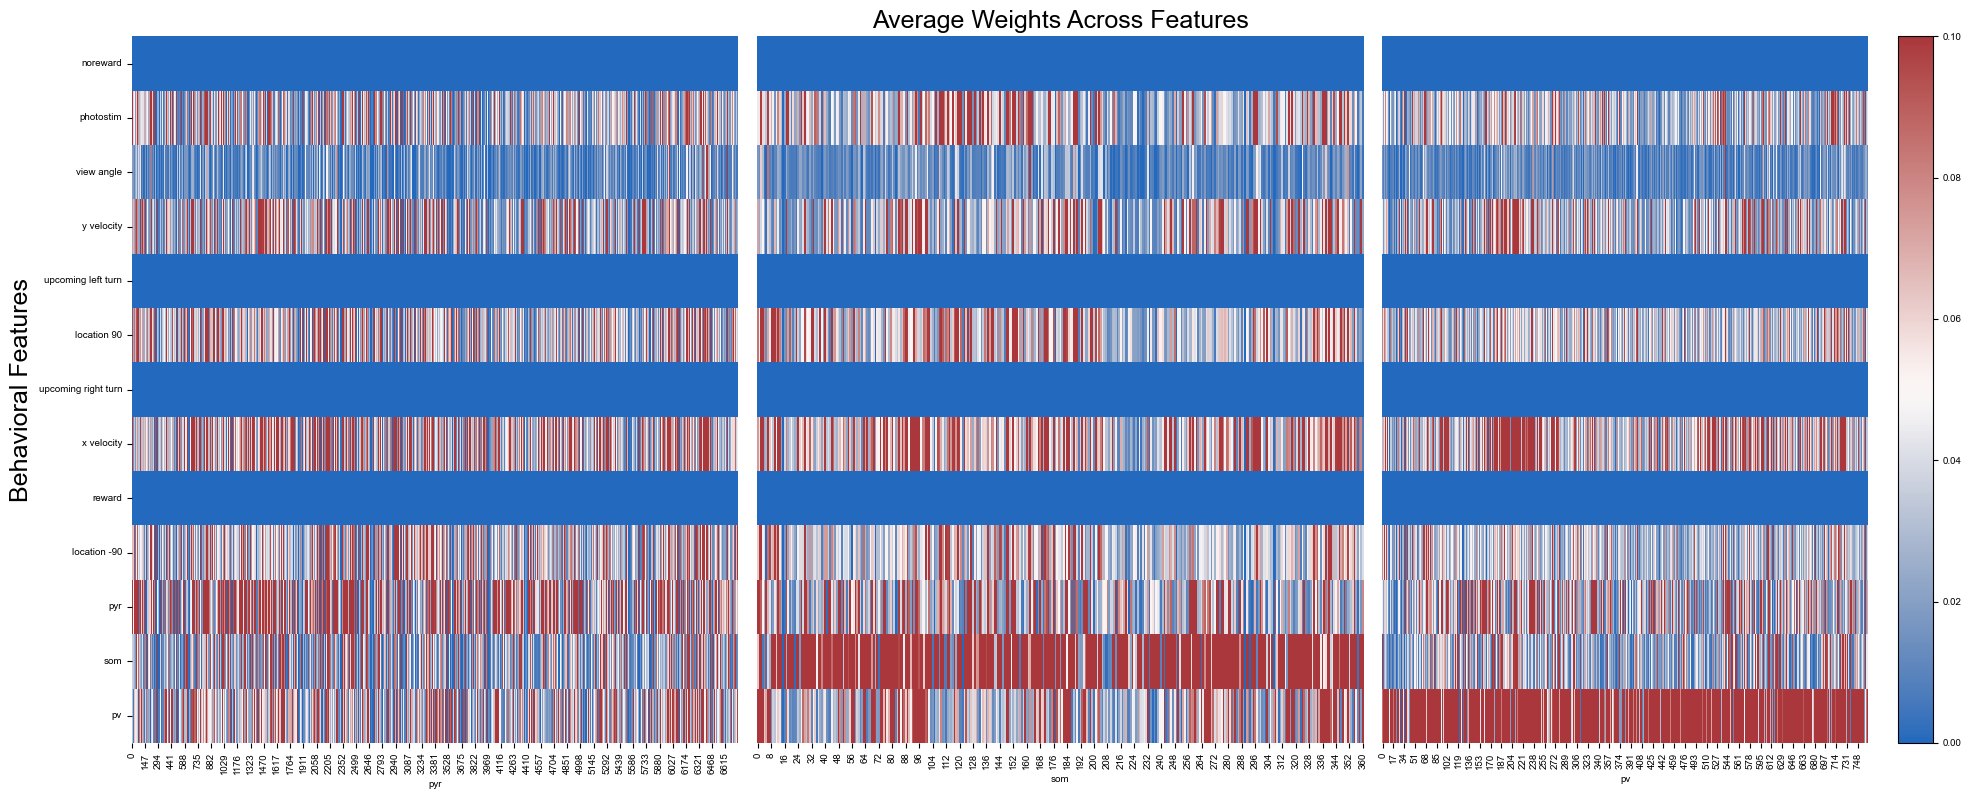

In [15]:
plotter.unique_features_heatmap_celltypes(max_beta_feature_unique,unique_feature_names,neuron_groups, minmax = (0, .1),model_type =model_types, no_abs=no_abs)
#max_beta_feature_unique, total_beta_feature_unique,mean_neuron_feature_unique

In [10]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_manager = analysisfun(data = None, plotter=plotter)

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
HA10-1L_2023-03-31
HE1-00_2023-05-30


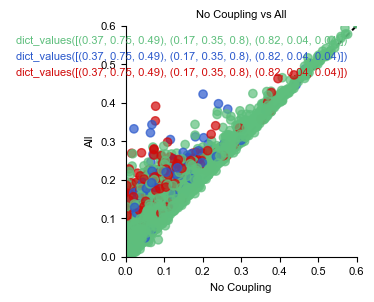

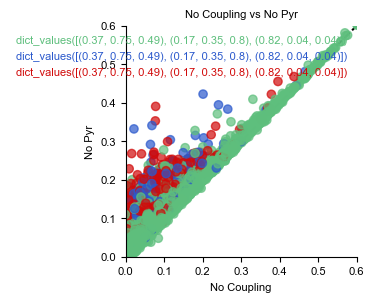

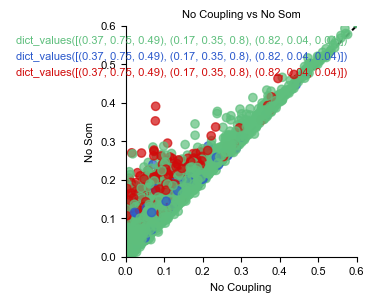

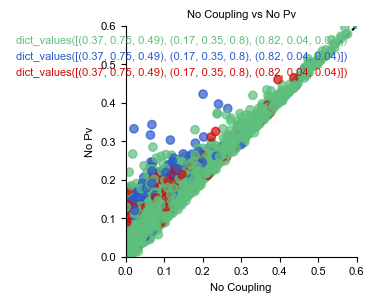

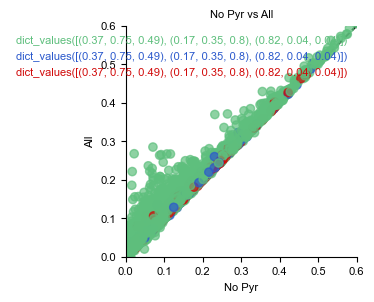

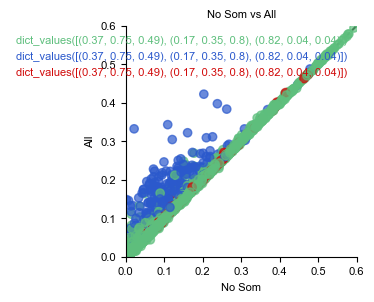

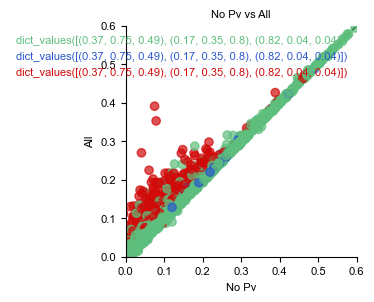

Outliers: (array([   0,    3,   10, ..., 7881, 7882, 7884], dtype=int64),)
Percent of cells that are outliers!: 0.34153455928979076


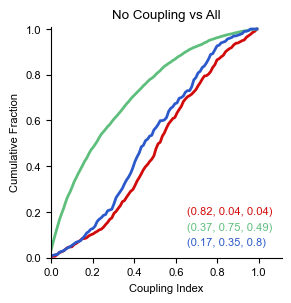

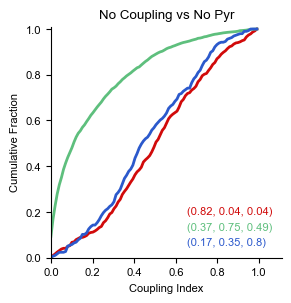

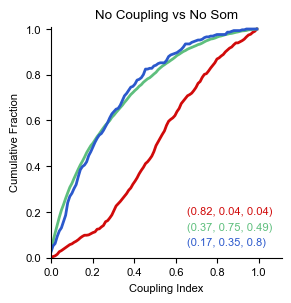

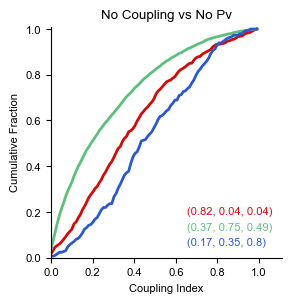

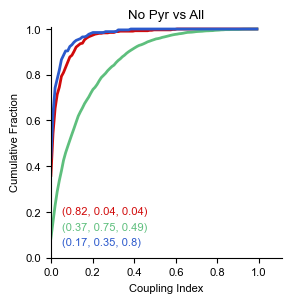

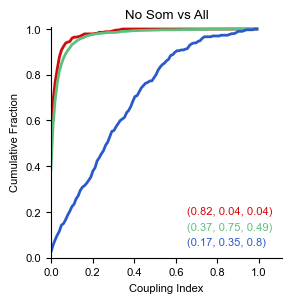

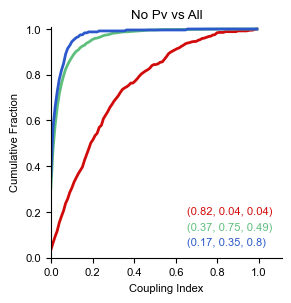

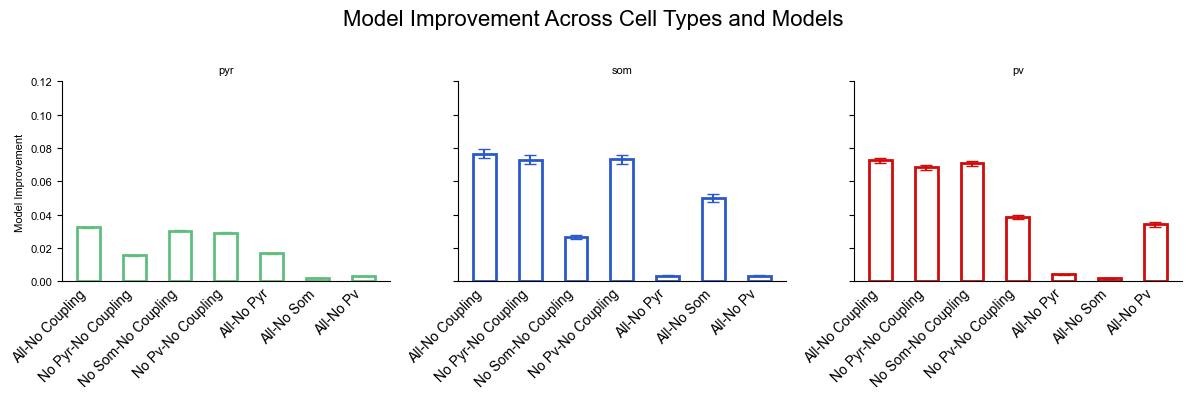

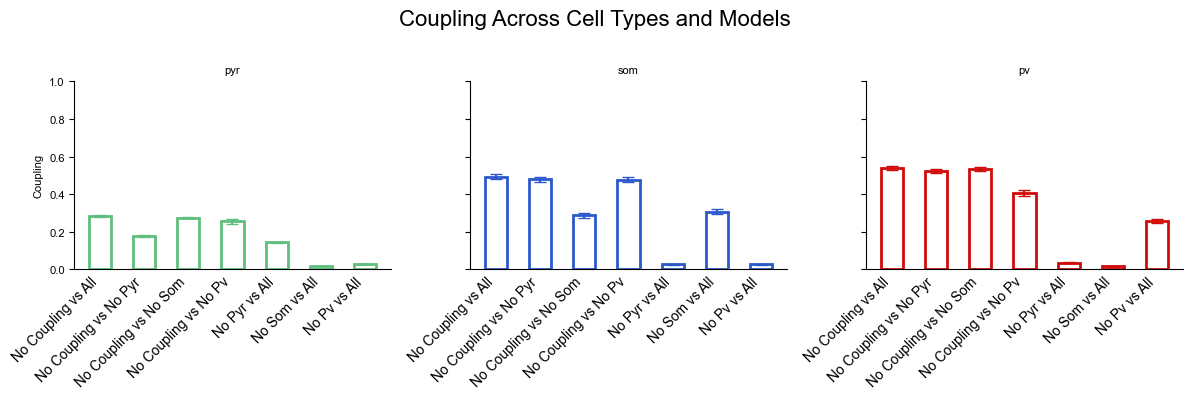

In [13]:
# PLOT EXAMPLE COUPLING INDICES FOR EXAMPLE RESULTS

# Aggregate model data
combined_B_weights, feature_names, other_weights, coupling_weights, coupling_indices,celltype_array, neuron_groups, start_indices = data_handler.aggregate_model_data_from_results(results, no_abs)

# plot scatter of coupling partial vs full model
analysis_manager.generate_scatter_plots(results, model_types)

# Example usage:
coupling_index_dir, model_improvement = analysis_manager.plot_coupling_index_across_datasets(results, model_types)

#PLOT Model improvement or coupling index across models!
#coupling_index_dir/ model_improvement

    
# Plot Model Improvement
save_string_improvement = f'bar_celltypes_model_diff_{model_types}.png'
plotter.bar_plot_separated(model_improvement, neuron_groups, measure_string='Model Improvement', save_path=save_string_improvement, minmax=(0,0.12))

# Plot Coupling Index
save_string_coupling = f'bar_celltypes_coupling_{model_types}.png'
plotter.bar_plot_separated(coupling_index_dir, neuron_groups, measure_string='Coupling', save_path=save_string_coupling, minmax=(0,1))

model type: Active, original length, 7885
model type: Active ITI, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Active ITI, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Active ITI, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Active ITI, original length, 7885
model type: Passive, original length, 7885
Recalculating coupling index using neurons present across all comparisons and models...
Cell Type: pyr, Number of common non-NaN neurons across all comparisons and models: 897
Cell Type: som, Number of common non-NaN neurons across all comparisons and models: 152
Cell Type: pv, Number of common non-NaN neurons across all comparisons and models: 309

PYR Cell Type: No Coupling vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs 

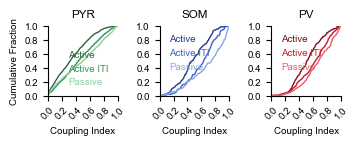


PYR Cell Type: No Pyr vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

SOM Cell Type: No Pyr vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

PV Cell Type: No Pyr vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002
model type: Active, pyr,6760, original length, 7885
model type: Active ITI, pyr,6760, original length, 7885
model type: Passive, pyr,6760, original length, 7885
model type: Active, som,361, original length, 7885
model type: Active ITI, som,361, original length, 7885
model type: Passive, som,361, original length, 7885
model type: Active, pv,764, original length, 7885
model type: Active ITI, pv,764, original length, 7885
model type: Passive, pv,764, original length, 7885


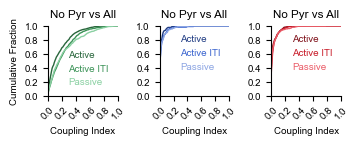


PYR Cell Type: No Som vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

SOM Cell Type: No Som vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

PV Cell Type: No Som vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002
model type: Active, pyr,6760, original length, 7885
model type: Active ITI, pyr,6760, original length, 7885
model type: Passive, pyr,6760, original length, 7885
model type: Active, som,361, original length, 7885
model type: Active ITI, som,361, original length, 7885
model type: Passive, som,361, original length, 7885
model type: Active, pv,764, original length, 7885
model type: Active ITI, pv,764, original length, 7885
model type: Passive, pv,764, original length, 7885


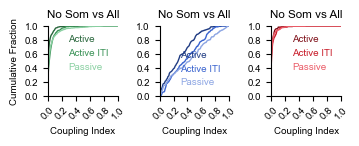


PYR Cell Type: No Pv vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

SOM Cell Type: No Pv vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002

PV Cell Type: No Pv vs All
Model Active vs Active ITI:
Observed Difference: nan, P-value: 0.0002
Model Active ITI vs Passive:
Observed Difference: nan, P-value: 0.0002
model type: Active, pyr,6760, original length, 7885
model type: Active ITI, pyr,6760, original length, 7885
model type: Passive, pyr,6760, original length, 7885
model type: Active, som,361, original length, 7885
model type: Active ITI, som,361, original length, 7885
model type: Passive, som,361, original length, 7885
model type: Active, pv,764, original length, 7885
model type: Active ITI, pv,764, original length, 7885
model type: Passive, pv,764, original length, 7885


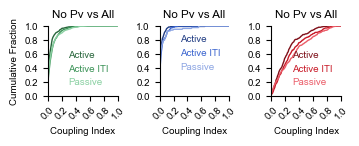

In [13]:
# NOW MAKE MODEL COMPARISONS!! Assuming you have three results dictionaries for each model

color_map_dict = {('pyr', 'Active'): '#29663C', ('pyr', 'Active ITI'): '#3A9256', ('pyr', 'Passive'): '#8AD0A2',
                   ('som', 'Active'): '#203C83', ('som', 'Active ITI'): '#3A64CF', ('som', 'Passive'): '#8CA5E3', 
                   ('pv', 'Active'): '#7F1019', ('pv', 'Active ITI'): '#C81927', ('pv', 'Passive'): '#EB5C68'}

# MAKE NEW INSTANCE OF PLOTTER AND ANALYSIS
plotter_context = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results, color_map_dict =  color_map_dict)
analysis_manager = analysisfun(data = None, plotter=plotter_context)

results_list = [results_pre,results_iti, results_pass]#[results_pre, results_pass]#[results_pre, results_iti, results_pass] # [updated_results_pre, updated_results_iti, updated_results_pass]
model_types = ['Active', 'Active ITI', 'Passive'] #['Active Task', 'Active ITI', 'Passive']

comparisons = [('No Coupling','All'),
        ('No Pyr','All'),
        ('No Som','All'),
        ('No Pv','All')]

coupling_index_by_celltype,_ = analysis_manager.plot_coupling_index_across_celltypes_cdf(results_list, 
         model_types, comparisons=comparisons,recalculate_modulation= True, figsize = (3*1.2,1.2*1.5)) #figsize = (3*1.3,1.3*1.5)

In [ ]:
# NOW MAKE MODEL COMPARISONS!! Assuming you have three results dictionaries for each model

color_map_dict = {('pyr', 'Active'): '#29663C', ('pyr', 'Active ITI'): '#3A9256', ('pyr', 'Passive'): '#8AD0A2',
                   ('som', 'Active'): '#203C83', ('som', 'Active ITI'): '#3A64CF', ('som', 'Passive'): '#8CA5E3', 
                   ('pv', 'Active'): '#7F1019', ('pv', 'Active ITI'): '#C81927', ('pv', 'Passive'): '#EB5C68'}

# MAKE NEW INSTANCE OF PLOTTER AND ANALYSIS
plotter_context = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results, color_map_dict =  color_map_dict)
analysis_manager = analysisfun(data = None, plotter=plotter_context)

results_list = [results_pre, results_pass]#[results_pre, results_pass]#[results_pre, results_iti, results_pass] # [updated_results_pre, updated_results_iti, updated_results_pass]
model_types = [ 'Active','Passive'] #['Active Task', 'Active ITI', 'Passive']

comparisons = [('No Coupling','All'),
        ('No Pyr','All'),
        ('No Som','All'),
        ('No Pv','All')]

coupling_index_by_celltype,_ = analysis_manager.plot_coupling_index_across_celltypes_cdf(results_list, 
         model_types, comparisons=comparisons,recalculate_modulation= True, figsize = (3*1.2,1.2*1.5)) #figsize = (3*1.3,1.3*1.5)


model type: Active, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Passive, original length, 7885
model type: Active, original length, 7885
model type: Passive, original length, 7885
Recalculating coupling index using neurons present across all comparisons and models...
Cell Type: pyr, Number of common non-NaN neurons across all comparisons and models: 1281
Cell Type: som, Number of common non-NaN neurons across all comparisons and models: 175
Cell Type: pv, Number of common non-NaN neurons across all comparisons and models: 349

PYR Cell Type: No Coupling vs All


KeyboardInterrupt: 

In [14]:
#Count to make sure neurons are the same across contexts
first_key = ('No Coupling', 'All')
# Loop through all cell types (second key)
for cell_type in coupling_index_by_celltype[first_key].keys():
    # Loop through all comparisons (last key)
    for comparison in coupling_index_by_celltype[first_key][cell_type].keys():
        # Extract the relevant array
        neurons_data = coupling_index_by_celltype[first_key][cell_type][comparison]
        # Count the number of non-NaN values
        non_nan_count = np.sum(~np.isnan(neurons_data))
        # Print the result
        print(f"Cell Type: {cell_type}, Comparison: {comparison}, Number of non-NaN neurons: {non_nan_count}")

Cell Type: pyr, Comparison: Active, Number of non-NaN neurons: 897
Cell Type: pyr, Comparison: Active ITI, Number of non-NaN neurons: 897
Cell Type: pyr, Comparison: Passive, Number of non-NaN neurons: 897
Cell Type: som, Comparison: Active, Number of non-NaN neurons: 152
Cell Type: som, Comparison: Active ITI, Number of non-NaN neurons: 152
Cell Type: som, Comparison: Passive, Number of non-NaN neurons: 152
Cell Type: pv, Comparison: Active, Number of non-NaN neurons: 309
Cell Type: pv, Comparison: Active ITI, Number of non-NaN neurons: 309
Cell Type: pv, Comparison: Passive, Number of non-NaN neurons: 309


('No Pyr', 'All') - pyr: Passive vs Active Wilcoxon p-value: 0.00000
('No Pyr', 'All') - som: Passive vs Active Wilcoxon p-value: 0.52673
('No Pyr', 'All') - pv: Passive vs Active Wilcoxon p-value: 0.99999
Bonferroni corrected alpha threshold: 0.01667
0.06258993479547703
('No Som', 'All') - pyr: Passive vs Active Wilcoxon p-value: 0.92244
('No Som', 'All') - som: Passive vs Active Wilcoxon p-value: 0.00000
('No Som', 'All') - pv: Passive vs Active Wilcoxon p-value: 0.99987
Bonferroni corrected alpha threshold: 0.01667
0.1445629027311745
('No Pv', 'All') - pyr: Passive vs Active Wilcoxon p-value: 1.00000
('No Pv', 'All') - som: Passive vs Active Wilcoxon p-value: 0.99998
('No Pv', 'All') - pv: Passive vs Active Wilcoxon p-value: 0.00000
Bonferroni corrected alpha threshold: 0.01667
0.07700508203672726
Comparison ('No Pyr', 'All'), cell type pyr, neurons used: 1281
cell_type pyr, 0.15565554621487732,0.21824548101035432
Comparison ('No Som', 'All'), cell type pyr, neurons used: 1281
cell_

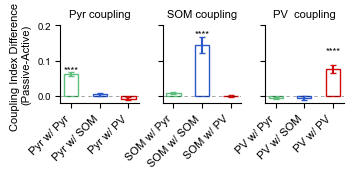

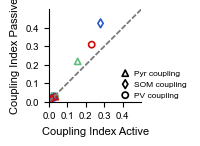

In [26]:
# COMPARE COUPLING ACROSS CONTEXTS
model_pairs = [('Passive','Active')] #more coupled, less coupled

comparisons_ = [('No Pyr','All'),
        ('No Som','All'),
        ('No Pv','All')]


# Generate x labels for plot!
cell_types_first_half = ['Pyr', 'SOM', 'PV']  #['Pyr coupling', 'SOM coupling', 'PV coupling']  # The first half (with 'w')
cell_types_second_half = ['Pyr', 'SOM', 'PV']  # The second half (without 'w')


xlabels = plotter.generate_xlabels(cell_types_first_half, cell_types_second_half,connector='w/')

# Call the function with the defined model pairs
analysis_manager.bar_plot_separated_coupling_index_diff(coupling_index_by_celltype, comparisons_, model_pairs, celltypecolors,
                                        'Coupling Index Difference \n(Passive-Active)', #'Coupling Index Difference (P-A)', #'Coupling Index Difference \n(Passive-Active)'
                                        bar_width=0.1,minmax = (-.02,0.2), xaxislabel = xlabels,save_path=save_results, figsize=(3*1.2,1.2*1.5))

markerstyles = ['^','d','o'] #['*','^','d','o']
model_pairs = [('Active','Passive')] #more coupled, less coupled
analysis_manager.scatter_plot_separated_celltype_mean(coupling_index_by_celltype, model_pairs, 'Coupling Index', minmax = (0,.5),markerstyles = markerstyles,version = 2, comparisons = comparisons_, figsize=(1.2,1.2))

('No Pyr', 'All') - pyr: Active ITI vs Active Wilcoxon p-value: 0.00000
('No Pyr', 'All') - som: Active ITI vs Active Wilcoxon p-value: 0.79400
('No Pyr', 'All') - pv: Active ITI vs Active Wilcoxon p-value: 0.69204
Bonferroni corrected alpha threshold: 0.01667
0.03987085863318054
('No Som', 'All') - pyr: Active ITI vs Active Wilcoxon p-value: 0.22938
('No Som', 'All') - som: Active ITI vs Active Wilcoxon p-value: 0.00000
('No Som', 'All') - pv: Active ITI vs Active Wilcoxon p-value: 0.80295
Bonferroni corrected alpha threshold: 0.01667
0.08820450331544895
('No Pv', 'All') - pyr: Active ITI vs Active Wilcoxon p-value: 0.13242
('No Pv', 'All') - som: Active ITI vs Active Wilcoxon p-value: 0.40336
('No Pv', 'All') - pv: Active ITI vs Active Wilcoxon p-value: 0.00000
Bonferroni corrected alpha threshold: 0.01667
0.04870587695606194
Comparison ('No Pyr', 'All'), cell type pyr, neurons used: 897
cell_type pyr, 0.16606957362161748,0.205940432254798
Comparison ('No Som', 'All'), cell type pyr,

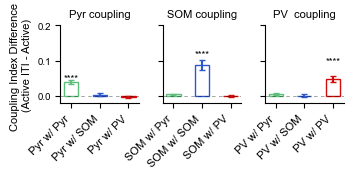

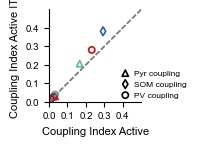

In [16]:
# COMPARE COUPLING ACROSS CONTEXTS
model_pairs = [('Active ITI','Active')] #more coupled, less coupled

comparisons_ = [('No Pyr','All'),
        ('No Som','All'),
        ('No Pv','All')]


# Generate x labels for plot!
cell_types_first_half = ['Pyr', 'SOM', 'PV']  #['Pyr coupling', 'SOM coupling', 'PV coupling']  # The first half (with 'w')
cell_types_second_half = ['Pyr', 'SOM', 'PV']  # The second half (without 'w')


xlabels = plotter.generate_xlabels(cell_types_first_half, cell_types_second_half,connector='w/')

# Call the function with the defined model pairs
analysis_manager.bar_plot_separated_coupling_index_diff(coupling_index_by_celltype, comparisons_, model_pairs, celltypecolors,
                                        'Coupling Index Difference \n(Active ITI - Active)', #'Coupling Index Difference (P-A)', #'Coupling Index Difference \n(Passive-Active)'
                                        bar_width=0.1,minmax = (-.02,0.2), xaxislabel = xlabels,save_path=save_results, figsize=(3*1.2,1.2*1.5))

markerstyles = ['^','d','o'] #['*','^','d','o']
model_pairs = [('Active','Active ITI')] #more coupled, less coupled
analysis_manager.scatter_plot_separated_celltype_mean(coupling_index_by_celltype, model_pairs, 'Coupling Index', minmax = (0,.5),markerstyles = markerstyles,version = 2, comparisons = comparisons_, figsize=(1.2,1.2))

In [13]:
# Import path setup
from utils.path_utils import setup_paths
base_dir = setup_paths()
from utils.general_stats import GeneralStats
stats = GeneralStats()  # instantiate it

import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

In [114]:
def bar_plot_separated_coupling_index_diff_test(coupling_index_by_celltype, comparisons, model_pairs, colors, measure_string, bar_width=0.5, save_path=None, minmax=(0, 0.1), xaxislabel = None, figsize = (3*1.3,1.3*1.5)):
        """
        Create a bar plot with error bars to compare coupling index differences across cell types within each comparison.

        Parameters:
        coupling_index_by_celltype: dict
            A nested dictionary where outer keys are comparisons, second-level keys are cell types, and inner keys are model types, with values as the coupling index.
        comparisons: list
            A list of comparisons to include in the plot.
        model_pairs: list of tuples
            A list of tuples where each tuple contains two model types to compare (e.g., [('Model_Pre', 'Model_ITI'), ...]).
        colors: dict
            A dictionary where keys are cell types and values are colors for the bars.
        measure_string: str
            The label for the y-axis.
        bar_width: float
            The width of the bars in the plot.
        save_path: str, optional
            The path to save the plot. If None, the plot is displayed instead of saved.
        minmax: tuple
            Tuple specifying the y-axis limits (min, max).
        """
        # For collecting all p-values for Bonferroni correction
        all_p_values = []

        # Set global font size and family 
        plt.rcParams.update({'font.size': 8, 'font.family': 'arial'})

        # Create a figure with subplots, one for each comparison
        fig, axs = plt.subplots(1, len(comparisons), figsize=figsize, sharey=True) #(3, 1) #1.26 is the actual ratio but have to increase to account for labels
        
        # Iterate over comparisons to create each subplot
        for i, comparison in enumerate(comparisons):
            ax = axs[i]  # Select the subplot
            all_pos = []
            bar_heights_al = []
            # Iterate over each cell type in the current comparison
            for j, (cell_type, cell_data) in enumerate(coupling_index_by_celltype[comparison].items()):
                # Calculate positions for each model comparison along the x-axis
                positions = np.arange(len(model_pairs)) + 1 + j * (bar_width + 0.1)
                all_pos.append(positions)
                means = []
                errors = []
                
                # Iterate over each model comparison and compute differences
                for model1, model2 in model_pairs:
                    if model1 in cell_data and model2 in cell_data:
                        differences = np.array(cell_data[model1]) - np.array(cell_data[model2])
                        means.append(np.nanmean(differences))
                        errors.append(np.nanstd(differences) / np.sqrt(np.sum(~np.isnan(differences))))  # Standard error ignoring NaNs
                    else:
                        means.append(np.nan)
                        errors.append(np.nan)
                
                # Create bar plot with uncolored inside and colored outlines
                bars = ax.bar(positions, means, yerr=errors, capsize=2, 
                            edgecolor=colors[cell_type],
                            facecolor='white', linewidth=1, width=bar_width, ecolor=colors[cell_type])
                
                # Get heights of the current bars
                # Get heights of the current bars
                bar_heights = [bar.get_height() for bar in bars]
                bar_heights_al.append(bar_heights)

            # variables to store statistics
            all_stats_dict = {}
            comparisons_list = []
            test_stats = []

            # Statistical tests for differences from zero using Wilcoxon signed-rank test
            significance_stars = []
            for model1, model2 in model_pairs:
                p_values_for_this_comparison = []
                for cell_type, cell_data in coupling_index_by_celltype[comparison].items():
                    if model1 in cell_data and model2 in cell_data:
                        differences = np.array(cell_data[model1]) - np.array(cell_data[model2])
                        #Remove NaNs
                        differences = differences[~np.isnan(differences)]
                        if np.sum(~np.isnan(differences)) > 0:
                            # Perform Wilcoxon signed-rank test against zero
                            stat, p_value = wilcoxon(differences, alternative='greater')
                            p_values_for_this_comparison.append(p_value)
                            all_p_values.append(p_value)
                            print(f"{comparison} - {cell_type}: {model1} vs {model2} Wilcoxon p-value: {p_value:.5f}")

                            comparisons_list.append((f"{comparison}_{cell_type}_{model1}", f"{comparison}_{cell_type}_{model2}"))
                            test_stats.append(stat)

                            # Collect bar positions for drawing lines and stars

                            ## save stats for each comparison
                            # Suppose you have stats for several groups:
                            stats_dict = {
                                'group1': stats.get_basic_stats(cell_data[model1]),
                                'group2': stats.get_basic_stats(cell_data[model2]),
                                # etc.
                            }

                            # Save stats for each group
                            label1 = f"{comparison}_{cell_type}_{model1}"
                            label2 = f"{comparison}_{cell_type}_{model2}"
                            all_stats_dict[label1] = stats.get_basic_stats(cell_data[model1])
                            all_stats_dict[label2] = stats.get_basic_stats(cell_data[model2])

            # Clean the measure string for saving
            safe_measure_string = measure_string.replace('\n', ' ').replace('/', '-').strip()


            # After the plotting loop, save all stats to a table
            if save_path:
                df_stats = stats.basic_stats_to_table(all_stats_dict, save_path=f'{save_path}/basic_stats_{safe_measure_string}.csv')
                df_tests = stats.to_table(comparisons_list, test_stats, p_values_for_this_comparison, save_path=f'{save_path}/stat_tests_{safe_measure_string}.csv',type = 'wilcoxon signed-rank test against zero')
            else:
                df_stats = stats.basic_stats_to_table(all_stats_dict)
                df_tests = stats.to_table(comparisons_list, test_stats, p_values_for_this_comparison,type = 'wilcoxon signed-rank test against zero')

            if xaxislabel is None:
                ax.set_xticks(np.arange(len(model_pairs)) + 1 + bar_width)
                ax.set_xticklabels([f'{model1} - {model2}' for model1, model2 in model_pairs], rotation=45, ha='right', fontsize=8)
                ax.tick_params(axis='x', which='major', length=0)
                # Set labels and title for each subplot
                #ax.set_title(f'{comparison}', fontsize=14)
            else:
                # Use provided x-axis labels for each subplot
                if i < len(xaxislabel):  # Ensure there are enough labels for each comparison
                    ax.set_xticks(np.squeeze(all_pos))
                    ax.set_xticklabels(xaxislabel[i], rotation=45, ha='right', fontsize=8)
                    #ax.set_title(f'{comparison}', fontsize=14)
                    ax.set_title(f'{xaxislabel[i][0][:3]} coupling', fontsize=8)
                else:
                    ax.set_xticks(np.arange(len(model_pairs)) + 1 + bar_width)
                    ax.set_xticklabels([f'{model1} - {model2}' for model1, model2 in model_pairs], rotation=45, ha='right', fontsize=8)

            # Clean up the appearance
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            if i == 0:
                ax.set_ylabel(f'{measure_string}', fontsize=8)

            ax.set_ylim(minmax[0], minmax[1])
            if minmax[0] < 0:
                ax.axhline(0, color='black', linewidth=0.5, linestyle=(0, (5, 5)), alpha=0.5) #axes[0].axvline(x=182, linestyle='dashed', color='k', alpha=1)
            

            # Calculate Bonferroni significance
            corrected_p_values, significance_stars = stats.calculate_bonferroni_significance(p_values_for_this_comparison)

            # Draw significance lines and stars
            for idx, (p, star) in enumerate(zip(corrected_p_values, significance_stars)):
                if star != 'ns':
                    bottom, top = axs[0].get_ylim()
                    top = minmax[1] - 0.1
                    top = bar_heights_al[idx][0]
                    print(top)
                    y = top + (idx * 0.02)  # Adjust y-coordinate
                    # x1 = bar_positions[idx] - bar_width / 2
                    # x2 = bar_positions[idx] + bar_width / 2
                    x1 = all_pos[idx]
                    plotter.add_significance_line(axs[i], x1, y=y, significance=star)

            
        
        # Add a global title for the figure
        #fig.suptitle(f'{measure_string} Differences Across Comparisons and Cell Types', fontsize=16)
        
        # Adjust layout
        #plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.tight_layout()
        plt.subplots_adjust(wspace=0.3)

        #to save svg so that we can edit texts!
        new_rc_params = {'text.usetex': False,
        "svg.fonttype": 'none'
        }
        plt.rcParams.update(new_rc_params)


        # Save plot if save_path is provided
        if save_path: 
            os.chdir(save_path)
            plt.savefig(f'bar_diff_{model_pairs[0][0]}-{model_pairs[0][1]}_coupling_celltypesv1.pdf', bbox_inches='tight')


def scatter_plot_separated_celltype_mean_test(coupling_index_by_celltype, model_pairs, measure_string, minmax=(0, 0.1),markerstyles = "o",version = 1,comparisons=None, figsize = (1.5,1.5)):
        """
        Create a scatter plot comparing mean coupling indices between two models for each cell type.

        Parameters:
        coupling_index_by_celltype: dict
            A nested dictionary where outer keys are comparisons, second-level keys are cell types, and inner keys are model types, with values as the coupling index.
        cell_types: list
            A list of cell types to include in the plot.
        model_pairs: list of tuples
            A list of tuples where each tuple contains two model types to compare (e.g., [('Model_Pre', 'Model_ITI'), ...]).
        colors: dict
            A dictionary where keys are cell types and values are colors for the scatter points.
        measure_string: str
            The label for the axes.
        save_path: str, optional
            The path to save the plot. If None, the plot is displayed instead of saved.
        minmax: tuple
            Tuple specifying the axis limits (min, max) for both x and y axes.
        markerstyles: str or list
            Marker style(s) for different comparisons.
        version: int
            Version of the plot style (1 or 2).
        comparisons: list, optional
            List of specific comparisons to include. If None, all comparisons in `coupling_index_by_celltype` are used.

        """
        # Set global font size and family 
        plt.rcParams.update({'font.size': 8, 'font.family': 'arial'})

        # Use all comparisons if none are provided
        if comparisons is None:
            comparisons = list(coupling_index_by_celltype.keys())
        
        cell_types = plotter.celltypecolors.keys()
        colors = plotter.celltypecolors

        if version ==1: 
            # Create a figure with subplots, one for each cell type
            fig, axs = plt.subplots(1, len(cell_types), figsize=figsize, sharex=True, sharey=True) # figsize=(9, 3)
            # Iterate over cell types to create each subplot
            for i, cell_type in enumerate(cell_types):
                ax = axs[i]  # Select the subplot
                handles = []  # To store scatter plot handles for the legend
                labels = []  # To store labels for the legend
                
                # Iterate over each comparison in the current cell type
                for cmp,comparison in comparison in enumerate(comparisons):
                    cell_data = coupling_index_by_celltype[comparison][cell_type]
                    
                    # Iterate over each model comparison and compute mean coupling indices
                    for model1, model2 in model_pairs:
                        if model1 in cell_data and model2 in cell_data:
                            mean_model1 = np.nanmean(cell_data[model1])  # Mean across neurons for model1
                            mean_model2 = np.nanmean(cell_data[model2])  # Mean across neurons for model2

                            # Plot the mean of model1 on the x-axis vs. model2 on the y-axis
                            scatter = ax.scatter(mean_model1, mean_model2, color=colors[cell_type], alpha=0.7, s=20, label=f'{model1} vs {model2}', edgecolor='black', marker = markerstyles[cmp])

                            # # Clean up the appearance
                            ax.spines['top'].set_visible(False)
                            ax.spines['right'].set_visible(False)
                            ax.set_box_aspect(1)

                            # Store the handle and label for legend
                            handles.append(scatter)
                            labels.append(f'{comparison[1]}')
                
                # Set labels and title for each subplot
                ax.set_title(f'{cell_type}', fontsize=8)
                if i == 0:
                    ax.set_ylabel(f'{measure_string} {model2}', fontsize=8)
                ax.set_xlabel(f'{measure_string} {model1}', fontsize=8)
                ax.set_xlim(minmax[0], minmax[1])
                ax.set_ylim(minmax[0], minmax[1])

                # Add a 45-degree diagonal line to show where x = y
                ax.plot([minmax[0], minmax[1]], [minmax[0], minmax[1]], linestyle='--', color='gray', linewidth=1)

                
                # Add the legend for this subplot
                ax.legend(handles, labels, loc= (.7,0), fontsize=6, frameon=False,handletextpad=0.1) #'lower right'

                ticks = np.arange(minmax[0], minmax[1], 0.1)
                plt.xticks(ticks)
                plt.yticks(ticks)

                # Adjust layout
                plt.tight_layout(rect=[0, 0, 1, 0.95])
                plt.tight_layout(rect=[0, 0, .80, 1]) #rect=[0, 0, 1, 0.95]
        
        else:
            # Create a figure with subplots, one for each cell type
            fig, axs = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=True) #figsize(3, 3)
            #fig, axs = plt.subplots(1, 1, figsize=(10,10), sharex=True, sharey=True)
            
            for i, cell_type in enumerate(cell_types):
                ax = axs  # Select the subplot
                handles = []  # To store scatter plot handles for the legend
                labels = []  # To store labels for the legend
                
                # Iterate over each comparison in the current cell type
                for cmp, comparison in enumerate(comparisons):
                    cell_data = coupling_index_by_celltype[comparison][cell_type]
                    
                    # Iterate over each model comparison and compute mean coupling indices
                    for model1, model2 in model_pairs:
                        if model1 in cell_data and model2 in cell_data:
                            non_nan1 = ~np.isnan(cell_data[model1])
                            non_nan2 = ~np.isnan(cell_data[model2])
                            good_neurons = non_nan1 & non_nan2
                            print(f'Comparison {comparison}, cell type {cell_type}, neurons used: {np.sum(good_neurons)}')
                            
                            mean_model1 = np.nanmean(cell_data[model1])  # Mean across neurons for model1
                            mean_model2 = np.nanmean(cell_data[model2])  # Mean across neurons for model2

                            # Plot the mean of model1 on the x-axis vs. model2 on the y-axis
                            #scatter = ax.scatter(mean_model1, mean_model2, color=colors[cell_type], alpha=0.7, s=50, label=f'{model1} vs {model2}', edgecolor='black', marker = markerstyles[cmp])
                            scatter = ax.scatter(mean_model1, mean_model2,facecolors='none',  alpha=1, s=20, label=f'{model1} vs {model2}', edgecolor=colors[cell_type], marker = markerstyles[cmp], linewidths=1)
                            print(f'cell_type {cell_type}, {mean_model1},{mean_model2}')

                            # # Clean up the appearance
                            ax.spines['top'].set_visible(False)
                            ax.spines['right'].set_visible(False)
                            ax.set_box_aspect(1)

                            # Store the handle and label for legend
                            handles.append(scatter)
                            labels.append(f'{comparison[0]}')
                
                # Set labels and title for each subplot
                # ax.set_title(f'{cell_type}', fontsize=8)
                if i == 0:
                    ax.set_ylabel(f'{measure_string} {model2}', fontsize=8)
                ax.set_xlabel(f'{measure_string} {model1}', fontsize=8)
                ax.set_xlim(minmax[0], minmax[1])
                ax.set_ylim(minmax[0], minmax[1])

                # Add a 45-degree diagonal line to show where x = y
                ax.plot([minmax[0], minmax[1]], [minmax[0], minmax[1]], linestyle='--', color='gray', linewidth=1)

                ticks = np.arange(minmax[0], minmax[1], 0.1)
                plt.xticks(ticks)
                plt.yticks(ticks)

                # Add the legend for this subplot
                labels = ["Pyr coupling", "SOM coupling", "PV coupling"]
                # After the loop is done and you have `handles` and `labels`
                import copy
                legend_handles = []
                for h in handles:
                    h_copy = copy.copy(h)
                    h_copy.set_edgecolor('black')  # Make the legend symbol black
                    h_copy.set_facecolor('none')   # Keep it consistent with facecolors='none' used in plotting
                    legend_handles.append(h_copy)
                ax.legend(legend_handles, labels, loc=(.7, 0), fontsize=6, frameon=False, handletextpad=0.1, labelcolor='black')
                
                # ax.legend(handles, labels, loc= (.7,0), fontsize=8, frameon=False,handletextpad=0.1) #'lower right'

        # Add a global title for the figure
        # fig.suptitle(f'{measure_string} Comparison Across Cell Types', fontsize=8)
        

        #to save svg so that we can edit texts!
        new_rc_params = {'text.usetex': False,
        "svg.fonttype": 'none'
        }
        plt.rcParams.update(new_rc_params)

        

        # Save plot if save_path is provided
        if plotter.save_results: 
            os.chdir(plotter.save_results)
            plt.savefig(f'scatter_{model1}_vs_{model2}_coupling_celltypes_version{version}.pdf', bbox_inches='tight')
        
        plt.show()


('No Pyr', 'All') - pyr: Active vs Passive Wilcoxon p-value: 1.00000
('No Pyr', 'All') - som: Active vs Passive Wilcoxon p-value: 0.47327
('No Pyr', 'All') - pv: Active vs Passive Wilcoxon p-value: 0.00001
Bonferroni corrected alpha threshold: 0.01667
0.007188109500425988
('No Som', 'All') - pyr: Active vs Passive Wilcoxon p-value: 0.07756
('No Som', 'All') - som: Active vs Passive Wilcoxon p-value: 1.00000
('No Som', 'All') - pv: Active vs Passive Wilcoxon p-value: 0.00013
Bonferroni corrected alpha threshold: 0.01667
0.0007574080485557102
('No Pv', 'All') - pyr: Active vs Passive Wilcoxon p-value: 0.00000
('No Pv', 'All') - som: Active vs Passive Wilcoxon p-value: 0.00002
('No Pv', 'All') - pv: Active vs Passive Wilcoxon p-value: 1.00000
Bonferroni corrected alpha threshold: 0.01667
0.0044368397342998776
0.0051390420024328195
Comparison ('No Pyr', 'All'), cell type pyr, neurons used: 1281
cell_type pyr, 0.15565554621487732,0.21824548101035432
Comparison ('No Som', 'All'), cell type p

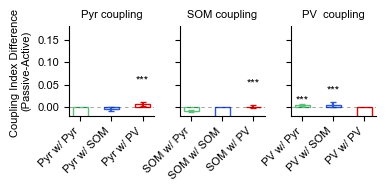

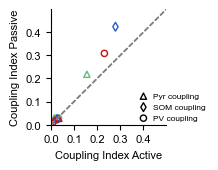

In [115]:
bar_plot_separated_coupling_index_diff_test(coupling_index_by_celltype, comparisons_, model_pairs, celltypecolors,
                                        'Coupling Index Difference \n(Passive-Active)', #'Coupling Index Difference \n(Passive-Active)'
                                        bar_width=0.1,minmax = (-.02,0.18), xaxislabel = xlabels,save_path=save_results)

markerstyles = ['^','d','o'] #['*','^','d','o']
model_pairs = [('Active','Passive')] #more coupled, less coupled
scatter_plot_separated_celltype_mean_test(coupling_index_by_celltype, model_pairs, 'Coupling Index', minmax = (0,.5),markerstyles = markerstyles,version = 2, comparisons = comparisons_)

Code below is testing different things and preliminary

In [142]:
response_type = 'diff_stim' #diff_stim, avg_ctrl_post, avg_ctrl_pre
dir1 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{response_type}.mat'
responder_type = 'sound_only_sig_cells'
dir2 = f'V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\{responder_type}.mat' #sound_only_sig_cells, opto_only_sig_cells,opto_sound_sig_cells,unmodulated
import scipy
# Load specific modulation indices!!
mod_idx = scipy.io.loadmat(dir1)
mod_index = mod_idx[response_type]
sig_cels = scipy.io.loadmat(dir2)
sig_cells = sig_cels[responder_type][0]-1 #minus one bc of MATLAB indexing
sig_cells = sig_cells.T
context = 1 #active = 0, passive = 1
print(f'shape sig_cells: {sig_cells.shape}')  # Check the shape of sig_cells

# Load the condition_array_trials structure
mouse_dates_keys
mat_data = scipy.io.loadmat('V:\Connie/results\opto_sound_2025\context\mod_index_specified_cells\differences_pre_post\dff\info.mat')
info = mat_data['info'][0][0]
# Assuming your mouse_date structure is loaded as a numpy array
mouse_dates = [
    item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
    for item in info['mouse_date'][0]
]
print(mouse_dates)

print(f'shape mod_index: {mod_index.shape}')  # Check the shape of mod_index
# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons = {}
mod_index_neurons = {}
# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx]
        print(f'{mouse_date}: {significant_neurons_al}')
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons[mouse_date] = significant_neurons_al
        current_mod = mod_index[idx][context] #[0,significant_neurons_al[0]]
        mod_index_neurons[mouse_date] = current_mod[0,significant_neurons_al[0]]#current_mod[significant_neurons_al[0]] #[0,significant_neurons_al[0]]
    else:
        print(f"No significant neurons found for {mouse_date}")

# Now you have a dictionary mapping each dataset to its significant neurons

print(f'total significant neurons: {len(sig_cells)}')

shape sig_cells: (24,)
['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12', 'HA2-1L_2023-05-05', 'HA1-00_2023-06-29', 'HA1-00_2023-08-28', 'HE4-1L1R_2023-08-21', 'HE4-1L1R_2023-08-24', 'HA10-1L_2023-04-10', 'HA10-1L_2023-04-17', 'HA10-1L_2023-04-12', 'HA11-1R_2023-04-07', 'HA11-1R_2023-05-01', 'HA11-1R_2023-05-02', 'HA2-1L_2023-04-28', 'HA2-1L_2023-05-01', 'HA1-00_2023-06-27', 'HA1-00_2023-07-07', 'HA1-00_2023-08-25', 'HE4-1L1R_2023-08-14', 'HE4-1L1R_2023-08-28', 'HE4-1L1R_2023-09-04', 'HE4-1L1R_2023-09-11', 'HA10-1L_2023-03-31', 'HE1-00_2023-05-30']
shape mod_index: (25, 2)
HA11-1R_2023-05-05: [[  0   5   7   8  28  34  44  45  48  50  54  63  65  67  80  81  82  83
   85  86  91  96  97  99 102 105 111 117 119 121 122 124 127 128 129 131
  133 134 137 138 139 140 142 145 151 153 158 163 166 167 172 178 189 190
  193 194 202 203 209 210 212 213 226 240 244 247 248 249 251 255 257 262
  266 268 275 277 278 282 287 288 290 297 298 299 301 302 303 313 315 316
  321 322 333 3

In [126]:
# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons = {}
mod_index_neurons = {}
# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx]
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons[mouse_date] = significant_neurons_al
        current_mod = mod_index[idx][0]
        mod_index_neurons[mouse_date] = current_mod[0,significant_neurons_al[0]]
    else:
        print(f"No significant neurons found for {mouse_date}")

In [122]:
# TO PLOT MOD VS COUPLING INDEX!
def binnedhex_model_dev_comparison(mean_deviance1, mean_deviance2, cell_ids, measure_string, measure_string2, colors=None, plot_lims=None, save_path=None, plot_lims_neg=None, gridsize=30):
    """
    Create a binned hexagonal plot comparing deviance explained of partial vs full models.
    
    Parameters:
        mean_deviance1 (array_like): Deviance explained for full model.
        mean_deviance2 (array_like): Deviance explained for partial model.
        cell_ids (array_like): IDs of cells.
        measure_string (str): The label for the x-axis.
        measure_string2 (str): The label for the y-axis.
        colors (dict, optional): Dictionary of colors for each cell type. Keys should be cell types and values should be colors.
        plot_lims (optional): Limits for x and y axis.
        save_path (optional): Path to save the plot.
        gridsize (int, optional): The size of the bins in the hexagonal plot. Default is 30.

    Returns:
        None
    """
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    
    # Create a hexbin plot
    hb = ax.hexbin(mean_deviance2, mean_deviance1, gridsize=gridsize, cmap='Blues', mincnt=1)
    
    # Add a color bar
    cb = fig.colorbar(hb, ax=ax,fraction=0.046, pad=0.04)
    cb.set_label('Counts')
    
    # Draw unity line
    # max_dev = max(max(mean_deviance2), max(mean_deviance1))
    # ax.plot([0, max_dev], [0, max_dev], '--', color='black', zorder=1, label='Unity Line')
    
    # Set labels and title
    ax.set_xlabel(f'{measure_string}', fontsize=14)
    ax.set_ylabel(f'{measure_string2}', fontsize=14)
    # ax.set_title(f'{measure_string} vs {measure_string2}', fontsize=14)

    # Set equal limits for x and y axes
    if plot_lims:
        ax.set_xlim(0, plot_lims)
        ax.set_ylim(0, plot_lims)
    if plot_lims_neg:
        ax.set_xlim(plot_lims_neg, plot_lims)
        # ax.set_ylim(plot_lims_neg, plot_lims)
        ax.set_ylim(plot_lims_neg, 1)
    
    # Clean up the appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)

    #to save svg so that we can edit texts!
    new_rc_params = {'text.usetex': False,
    "svg.fonttype": 'none'
    }
    plt.rcParams.update(new_rc_params)
    
    # Save plot if save_path is provided
    if save_path: 
        plt.savefig(save_path, bbox_inches='tight', format='svg')
    
    # Show plot
    plt.show()

def binned_model_dev_comparison(mean_deviance1, mean_deviance2, cell_ids, measure_string, measure_string2, colors=None, plot_lims=None, save_path=None, plot_lims_neg=None, num_bins=6):
    """
    Create a binned scatter plot comparing deviance explained of partial vs full models.
    
    Parameters:
        mean_deviance1 (array_like): Deviance explained for full model.
        mean_deviance2 (array_like): Deviance explained for partial model.
        cell_ids (array_like): IDs of cells.
        measure_string (str): The label for the x-axis.
        measure_string2 (str): The label for the y-axis.
        colors (dict, optional): Dictionary of colors for each cell type. Keys should be cell types and values should be colors.
        plot_lims (optional): Limits for x and y axis.
        save_path (optional): Path to save the plot.
        num_bins (int, optional): The number of bins to use for binning the data. Default is 20.

    Returns:
        None
    """
    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    
    # Bin the data along the x-axis (mean_deviance2)
    bins = np.linspace(min(mean_deviance2), max(mean_deviance2), num_bins)
    print(bins)
    bin_means = []
    bin_means_x = []
    
    # For each bin, calculate the mean of y (mean_deviance1) for points in that bin
    for i in range(len(bins) - 1):
        bin_mask = (mean_deviance2 >= bins[i]) & (mean_deviance2 < bins[i + 1])
        bin_mean_y = np.mean(mean_deviance1[bin_mask]) if np.any(bin_mask) else np.nan
        bin_mean_x = np.mean(mean_deviance2[bin_mask]) if np.any(bin_mask) else np.nan
        bin_means.append(bin_mean_y)
        bin_means_x.append(bin_mean_x)
    
    # Remove NaN values (if any bins are empty)
    bin_means = np.array(bin_means)
    bin_means_x = np.array(bin_means_x)
    valid_bins = ~np.isnan(bin_means) & ~np.isnan(bin_means_x)
    bin_means = bin_means[valid_bins]
    bin_means_x = bin_means_x[valid_bins]
    
    # Plot the binned data
    ax.plot(bin_means_x, bin_means, marker='o', linestyle='-', color='black', label='Binned Data')
    
    # Draw unity line
    # max_dev = max(max(mean_deviance2), max(mean_deviance1))
    # ax.plot([0, max_dev], [0, max_dev], '--', color='black', zorder=1, label='Unity Line')
    
    # Set labels and title
    ax.set_xlabel(f'{measure_string}', fontsize=14)
    ax.set_ylabel(f'{measure_string2}', fontsize=14)
    #ax.set_title(f'{measure_string} vs {measure_string2}', fontsize=14)

    # Set equal limits for x and y axes
    if plot_lims:
        ax.set_xlim(0, plot_lims)
        ax.set_ylim(0, plot_lims)
    if plot_lims_neg:
        ax.set_xlim(plot_lims_neg, plot_lims)
        ax.set_ylim(plot_lims_neg, plot_lims)
    
    # Clean up the appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)

    #to save svg so that we can edit texts!
    new_rc_params = {'text.usetex': False,
    "svg.fonttype": 'none'
    }
    plt.rcParams.update(new_rc_params)

    # Save plot if save_path is provided
    if save_path: 
        plt.savefig(f'{save_path}', bbox_inches='tight', format='svg')
    
    # Show plot
    plt.show()

def binned_model_dev_comparison_by_cell_type(mean_deviance1, mean_deviance2, cell_ids, measure_string, measure_string2, colors=None, plot_lims=None, save_path=None, plot_lims_neg=None, num_bins=6):
    """
    Create a binned scatter plot comparing deviance explained of partial vs full models, binned by cell type.
    
    Parameters:
        mean_deviance1 (array_like): Deviance explained for full model.
        mean_deviance2 (array_like): Deviance explained for partial model.
        cell_ids (array_like): IDs of cells.
        measure_string (str): The label for the x-axis.
        measure_string2 (str): The label for the y-axis.
        colors (dict, optional): Dictionary of colors for each cell type. Keys should be cell types and values should be colors.
        plot_lims (optional): Limits for x and y axis.
        save_path (optional): Path to save the plot.
        num_bins (int, optional): The number of bins to use for binning the data. Default is 20.

    Returns:
        None
    """

    # Set global font size and family 
    plt.rcParams.update({'font.size': 14, 'font.family': 'arial'})
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))

    # Get unique cell types from cell_ids
    cell_types = np.unique(cell_ids)
    
    # Set up default colors if not provided
    if colors is None:
        colormap = plt.cm.plasma
        color_dict = {cell_type: colormap(i / len(cell_types)) for i, cell_type in enumerate(cell_types)}
    else:
        color_dict = colors
    
    # Bin the data and plot separately for each cell type
    for cell_type in cell_types:
        print(cell_type)
        # Select data for the current cell type
        type_mask = np.array(cell_ids) == cell_type
        type_deviance1 = mean_deviance1[type_mask]
        type_deviance2 = mean_deviance2[type_mask]
        

        # Handle NaNs by creating valid masks
        valid_mask = ~np.isnan(type_deviance1) & ~np.isnan(type_deviance2)
        type_deviance1 = type_deviance1[valid_mask]
        type_deviance2 = type_deviance2[valid_mask]

        # Skip this cell type if there's no valid data after removing NaNs
        if len(type_deviance1) == 0 or len(type_deviance2) == 0:
            print(f"Skipping cell type {cell_type} due to no valid data after removing NaNs")
            continue

        # Debugging: print out the first few elements of each array for this cell type

        # Bin the data along the x-axis (mean_deviance2)
        bins = np.linspace(min(type_deviance2), max(type_deviance2), max(2, num_bins))  # Ensure at least 2 bins
        num2test = .1
        bins = np.linspace(-1*(num2test),num2test, num_bins+1) # np.linspace(-1*(num2test),num2test, num_bins+1)
        print(f"Bins for cell type {cell_type}: {bins}")
        bin_means_y = []
        bin_means_x = []
        
        for i in range(len(bins) - 1):
            bin_mask = (type_deviance2 >= bins[i]) & (type_deviance2 < bins[i + 1])
            if np.any(bin_mask):
                bin_mean_y = np.mean(type_deviance1[bin_mask])
                bin_mean_x = np.mean(type_deviance2[bin_mask])
                bin_means_y.append(bin_mean_y)
                bin_means_x.append(bin_mean_x)

        # Convert lists to numpy arrays
        bin_means_y = np.array(bin_means_y)
        bin_means_x = np.array(bin_means_x)

        # Plot the binned data for the current cell type
        if len(bin_means_x) > 0 and len(bin_means_y) > 0:  # Only plot if data exists after binning
            ax.plot(bin_means_x, bin_means_y, marker='o', linestyle='-', color=color_dict[cell_type], label=f'{cell_type}')
        else:
            print(f"No valid bins for cell type {cell_type}")

    # Set labels and title
    ax.set_xlabel(f'{measure_string}', fontsize=14)
    ax.set_ylabel(f'{measure_string2}', fontsize=14)

    # Set equal limits for x and y axes
    if plot_lims:
        ax.set_xlim(0, plot_lims)
        ax.set_ylim(0, plot_lims)
    if plot_lims_neg:
        ax.set_xlim(plot_lims_neg, plot_lims)
        ax.set_ylim(plot_lims_neg, plot_lims)

    ax.set_xlim(-1*(num2test),num2test)
    ax.set_ylim(-1*(num2test),1)
    
    # Add a legend with colors corresponding to cell types
    ax.legend(frameon=False, loc='upper right')

    # Clean up the appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_box_aspect(1)

    #to save svg so that we can edit texts!
    new_rc_params = {'text.usetex': False,
    "svg.fonttype": 'none'
    }
    plt.rcParams.update(new_rc_params)

    # Save plot if save_path is provided
    if save_path: 
        plt.savefig(f'{save_path}', bbox_inches='tight', format='svg')
    
    # Show plot
    plt.show() 



In [140]:
def threshold_modulation_index(mod_indices, full_data, partial_data,
                                lower_bound=None, upper_bound=None, abs_thresh=None):
    mod_indices_np = np.array(mod_indices, dtype=np.float64)
    # Create a boolean mask that starts with all True
    include_mask = np.ones_like(mod_indices_np, dtype=bool)
    # Apply lower bound
    if lower_bound is not None:
        include_mask &= mod_indices_np > lower_bound
    # Apply upper bound
    if upper_bound is not None:
        include_mask &= mod_indices_np < upper_bound
    # Apply absolute threshold (overrides previous if set)
    if abs_thresh is not None:
        include_mask = np.abs(mod_indices_np) < abs_thresh
    # Invert the mask to find outliers to be NaN'd
    mod_outliers = np.where(~include_mask)[0]
    print(f"Thresholding {len(mod_outliers)} cells based on ΔStim thresholds")
    # Apply thresholding
    for idx in mod_outliers:
        mod_indices[idx] = np.nan
        full_data[idx] = np.nan
        partial_data[idx] = np.nan
    return mod_indices, full_data, partial_data

from scipy.stats import ttest_ind
import numpy as np
def analyze_coupling_by_delta_stim_sign(mod_indices, coupling_index,threshold = 0, plot = True):
    """
    Compare coupling index between ΔStim < 0 (suppressed) and ΔStim > 0 (enhanced) neurons.
    Parameters:
        mod_indices (array-like): ΔStim modulation indices for each neuron.
        coupling_index (array-like): Coupling index values for each neuron.
    Returns:
        dict: Mean coupling for each group, t-test results, and sample sizes.
    """
    mod_indices = np.array(mod_indices)
    coupling_index = np.array(coupling_index)
    # Filter out NaNs
    valid = ~np.isnan(mod_indices) & ~np.isnan(coupling_index)
    mod_indices = mod_indices[valid]
    coupling_index = coupling_index[valid]
    # Group based on sign of ΔStim
    suppressed = coupling_index[mod_indices < threshold]
    enhanced = coupling_index[mod_indices > threshold]
    # T-test
    t_stat, p_value = ttest_ind(suppressed, enhanced, equal_var=False)

    # Convert to numpy and filter NaNs
    coupling_values = np.array(coupling_index)
    delta_stim_values = np.array(mod_indices)
    valid_mask = ~np.isnan(coupling_values) & ~np.isnan(delta_stim_values)
    coupling_values = coupling_values[valid_mask]
    delta_stim_values = delta_stim_values[valid_mask]
    # Split by sign
    suppressed_mask = delta_stim_values < threshold
    enhanced_mask = delta_stim_values > threshold
    suppressed_coupling = coupling_values[suppressed_mask]
    enhanced_coupling = coupling_values[enhanced_mask]
    # Stats
    mean_suppressed = np.mean(suppressed_coupling)
    mean_enhanced = np.mean(enhanced_coupling)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.hist(suppressed_coupling, bins=30, alpha=0.6, label=f'Suppressed (ΔStim < {threshold})', color='red')
        plt.hist(enhanced_coupling, bins=30, alpha=0.6, label=f'Enhanced (ΔStim > {threshold})', color='green')
        plt.axvline(mean_suppressed, color='red', linestyle='--')
        plt.axvline(mean_enhanced, color='green', linestyle='--')
        plt.title(f'Coupling Index by ΔStim Sign')
        plt.xlabel('Coupling Index')
        plt.ylabel('Count')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        'mean_suppressed': np.mean(suppressed),
        'mean_enhanced': np.mean(enhanced),
        'n_suppressed': len(suppressed),
        'n_enhanced': len(enhanced),
        't_stat': t_stat,
        'p_value': p_value
    }

def generate_scatter_plots_v2(results, celltypecolors, save_results, model_type, significant_neurons=None, mod_index_neurons=None, abs = 0, measure_string = 'Sound Index', mod_index_threshold=None):
    # Initialize an empty dictionary to store the mean deviance explained values across all datasets
    mean_dev_dict = {
        'No Coupling': [],
        'All': [],
        'No Pyr': [],
        'No Som': [],
        'No Pv': []
    }
    
    # Initialize a list to store all cell labels and modulation indices
    cell_labels = []
    mod_indices = []

    
    # Loop over each dataset in the results dictionary
    for dataset_key, dataset in results.items():
        if dataset_key in mod_index_neurons.keys():
            print(dataset_key)
            # Determine the cell labels based on significant neurons if provided
            if significant_neurons and dataset_key in significant_neurons:
                cell_ids = significant_neurons[dataset_key][0]
            else:
                cell_ids = range(len(dataset['celltype_array']))  # Default to all cells

            # Append the data from each dataset to the corresponding list in mean_dev_dict
            mean_dev_dict['No Coupling'].extend(dataset['mean_dev_behav'][cell_ids])
            mean_dev_dict['All'].extend(dataset['mean_dev'][cell_ids])
            mean_dev_dict['No Pyr'].extend(dataset['mean_dev_no_pyr'][cell_ids])
            mean_dev_dict['No Som'].extend(dataset['mean_dev_no_som'][cell_ids])
            mean_dev_dict['No Pv'].extend(dataset['mean_dev_no_pv'][cell_ids])

            
            # Map cell IDs to cell types and add to the cell_labels list
            cell_types = {
                0: 'pyr',
                1: 'som',
                2: 'pv',
            }
            cell_labels.extend([cell_types[dataset['celltype_array'][i]] for i in cell_ids])
            
            # Append modulation indices if provided
            mod_indices.extend(mod_index_neurons[dataset_key])
            
            # if mod_index_neurons and dataset_key in mod_index_neurons:
            #     mod_indices.extend(mod_index_neurons[dataset_key])
            # else:
            #     mod_indices.extend([None] * len(cell_ids))  # Use None if no modulation index available

            outlier_indices_all = np.where(np.array(mean_dev_dict['All']) < 0.05)
            num_cells = np.shape(mean_dev_dict['All'])[0]
            print(f"Outliers: {outlier_indices_all}")
            print(f"Percent of cells that are outliers!: {outlier_indices_all[0].size / num_cells}")
            
            # Create scatter plots and calculate coupling index for each comparison
            

            # Convert to np.float64
            full_data = np.array(mean_dev_dict['All']).astype(np.float64)
            partial_data = np.array(mean_dev_dict['No Coupling']).astype(np.float64)

            # NaN outlier indices
            full_data[outlier_indices_all] = np.nan
            partial_data[outlier_indices_all] = np.nan
            print(outlier_indices_all)
            for idx in outlier_indices_all[0]:
                mod_indices[idx] = np.nan

            mod_indices, full_data, partial_data = threshold_modulation_index(
                mod_indices,
                full_data,
                partial_data,
                lower_bound = None,      # optional: include only ΔStim > -0.2
                upper_bound = mod_index_threshold,       # optional: include only ΔStim < 0.2
                abs_thresh = None        # optional: override and use |ΔStim| < threshold
            )

            # # Threshold modulation index 
            # if mod_index_threshold is not None:
            #     mod_indices_np = np.array(mod_indices, dtype=np.float64)
            #     mod_outliers = np.where(np.abs(mod_indices_np) < mod_index_threshold)[0]
            #     print(f"Thresholding {len(mod_outliers)} cells with ΔStim < {mod_index_threshold}")
            #     for idx in mod_outliers:
            #         mod_indices[idx] = np.nan
            #         full_data[idx] = np.nan
            #         partial_data[idx] = np.nan

            # Calculate coupling index
            coupling_index = analysis_manager.calculate_coupling_index(full_data, partial_data)
    
    print(f"length mod {len(mod_indices)} , length coupling {len(mean_dev_dict['All'])}")
    # Change directory to the results folder
    os.chdir(save_results)
    
    # List of comparisons
    comparisons = [
        ('No Coupling', 'All'),
        ('No Coupling', 'No Pyr'),
        ('No Coupling', 'No Som'),
        ('No Coupling', 'No Pv'),
        ('No Pyr', 'All'),
        ('No Som', 'All'),
        ('No Pv', 'All')
    ]
    
    # Now, plot coupling vs modulation index
    if mod_index_neurons:
        coupling_values = coupling_index #mean_dev_dict['All'] 
        if abs:
            modulation_index = np.abs(mod_indices)
        else:
            modulation_index = mod_indices
        
        
        # Plot the coupling vs modulation index
        save_string = f'coupling_vs_mod_index_{model_type}.png'
        save_string = f'coupling_vs_mod_index_{model_type}.pdf'
        #save_string = f'coupling_vs_mod_index_{model_type}.svg'

        label2 = 'Coupling Index'
        label1 = measure_string
        
        plotter.scatter_model_dev_comparison(coupling_values, modulation_index, cell_labels, label1, label2, celltypecolors, 1, save_string,plot_lims_neg = -.5)
        # from scipy.stats import pearsonr
        # r, p = pearsonr(coupling_values, modulation_index)
        # print(f'Pearson r = {r:.2f}, p = {p:.4f}')

        # m, b = np.polyfit(coupling_values, modulation_index, 1)
        # ax.plot(coupling_values, m * coupling_values + b, color='gray', linestyle='--')

        # import numpy as np
        from scipy.stats import pearsonr

        # Convert to numpy arrays
        coupling_values = np.array(coupling_values)
        modulation_index = np.array(modulation_index)

        # Filter out NaNs from either array
        valid_mask = ~np.isnan(coupling_values) & ~np.isnan(modulation_index)
        coupling_clean = coupling_values[valid_mask]
        mod_index_clean = modulation_index[valid_mask]

        r, p = pearsonr(coupling_clean, mod_index_clean )
        print(f'Pearson r = {r:.2f}, p = {p:.4f}')

        # from scipy.stats import zscore
        # coupling_values = zscore(coupling_clean)
        # modulation_index = zscore(mod_index_clean)
        # plotter.scatter_model_dev_comparison(coupling_values, modulation_index, cell_labels, label1, label2, celltypecolors, 5, save_string,plot_lims_neg = -2)
        



        binnedhex_model_dev_comparison(coupling_values, modulation_index, cell_labels, label1, label2, celltypecolors, .2, save_string, plot_lims_neg=-.2 )

        save_string = f'binned_coupling_vs_mod_index_pass_{model_type}.pdf'
        binned_model_dev_comparison_by_cell_type( coupling_values, modulation_index,cell_labels, label1, label2, celltypecolors, 1, save_string,num_bins=3, plot_lims_neg=-.5 ) #_by_cell_type


        result = analyze_coupling_by_delta_stim_sign(mod_indices, coupling_index, threshold = .05, plot = True)
        print(f"Suppressed mean: {result['mean_suppressed']:.3f}, n={result['n_suppressed']}")
        print(f"Enhanced mean: {result['mean_enhanced']:.3f}, n={result['n_enhanced']}")
        print(f"T-statistic: {result['t_stat']:.3f}, p-value: {result['p_value']:.4f}")

        #scatter_coupling_vs_modulation(coupling_values, modulation_index, cell_labels, celltypecolors, 0.6, save_string)


In [702]:
plotter.save_results

'W:\\Connie/results\\Bassi2025\\glm_coupling'

In [695]:
plotter.celltypecolors

{'pyr': (0.37, 0.75, 0.49), 'som': (0.17, 0.35, 0.8), 'pv': (0.82, 0.04, 0.04)}

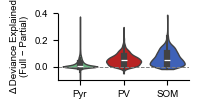

In [721]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def plot_delta_deviance_violin_by_celltype(plotter,results_pre, lower_bound=-.2, upper_bound=1, figsize=(6, 4), save_path=None, save_string = ''):
    """
    Plots violin plots of delta deviance explained (Full - Partial) across cell types.
    Assumes:
        results_pre[dataset][f'mean_dev{model_type}_full']: full model deviance
        results_pre[dataset][f'mean_dev{model_type}_partial']: partial model deviance
        results_pre[dataset]['neuron_groups']: dict with cell type keys ('pyr', 'pv', 'som') and neuron indices
    """
    delta_devs_by_celltype = {'pyr': [], 'pv': [], 'som': []}
    for dataset in results_pre.keys():
        full_key = f'mean_dev'
        partial_key = f'mean_dev_behav'
        full_dev = results_pre[dataset][full_key]
        partial_dev = results_pre[dataset][partial_key]
        # Clean deviance values
        full_dev = np.clip(full_dev, lower_bound, upper_bound)
        partial_dev = np.clip(partial_dev, lower_bound, upper_bound)
        delta_dev = full_dev - partial_dev  # difference in deviance explained due to coupling
        neuron_groups = results_pre[dataset]['neuron_groups']
        for celltype in delta_devs_by_celltype.keys():
            if celltype in neuron_groups:
                indices = neuron_groups[celltype]
                vals = delta_dev[indices]
                vals = vals[~np.isnan(vals)]
                delta_devs_by_celltype[celltype].extend(vals)
    # Create violin plot
    celltype_order = ['pyr', 'pv', 'som']
    palette = [plotter.celltypecolors[ct] for ct in celltype_order]
    plt.figure(figsize=figsize)
    sns.violinplot(data=[delta_devs_by_celltype['pyr'],
                         delta_devs_by_celltype['pv'],
                         delta_devs_by_celltype['som']],
                   inner='box', cut=0, linewidth=1,
                   palette=palette)
    plt.xticks([0, 1, 2], ['Pyr', 'PV', 'SOM'])
    plt.ylabel("Δ Deviance Explained\n(Full − Partial)")
    # plt.title("Coupling Contribution by Cell Type")
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    plt.ylim(-.1,.4) #set y limit
    sns.despine()
    plt.tight_layout()
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        plt.savefig(f'{save_path}violin_dev_explained_diff_celltypes_{save_string}.pdf', dpi=300, bbox_inches='tight')
    plt.show()

plot_delta_deviance_violin_by_celltype(plotter,results_pass, lower_bound=-.2, upper_bound=1, figsize=(2, 1.1), save_path=f'{plotter.save_results}/supplement/',save_string = 'passive')


<>:17: SyntaxWarning: "is" with a literal. Did you mean "=="?
<>:17: SyntaxWarning: "is" with a literal. Did you mean "=="?
C:\Users\runyan1\AppData\Local\Temp\ipykernel_28568\665366558.py:17: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if model_ex is 'pre':


HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-10
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HE4-1L1R_2023-09-11
HA10-1L_2023-03-31
HE1-00_2023-05-30
HA11-1R_2023-05-05
Outliers: (array([  0,   1,   5,   6,   8,   9,  10,  12,  13,  14,  15,  16,  18,
        19,  20,  22,  24,  25,  26,  28,  29,  30,  31,  34,  35,  36,
        39,  40,  41,  42,  43,  44,  45,  46,  49,  51,  52,  54,  55,
        57,  58,  59,  60,  61,  62,  63,  64,  66,  67,  68,  69,  70,
        71,  72,  73,  75,  77,  78,  79,  80,  82,  83,  84,  87,  90,
        91,  93,  94,  98,  99, 101, 102, 103], dtype=int64),)
Percent of cells that are outliers!: 0.7019230769230769
(array([  0,   1,   

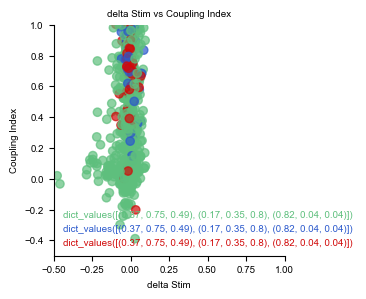

Pearson r = 0.21, p = 0.0000


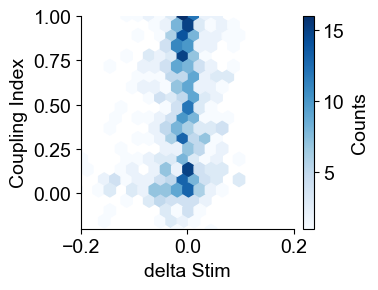

pv
Bins for cell type pv: [-0.1        -0.03333333  0.03333333  0.1       ]
pyr
Bins for cell type pyr: [-0.1        -0.03333333  0.03333333  0.1       ]
som
Bins for cell type som: [-0.1        -0.03333333  0.03333333  0.1       ]


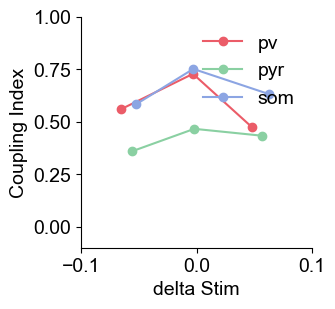

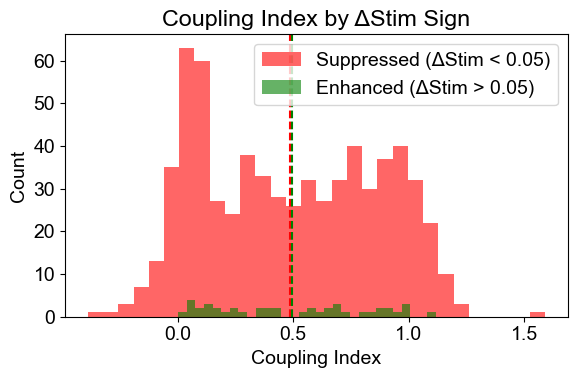

Suppressed mean: 0.485, n=665
Enhanced mean: 0.493, n=43
T-statistic: -0.150, p-value: 0.8817


In [143]:
if context == 0:
    results = results_pre
    model_types = 'GLM_3nmf_pre'
    model_ex = 'pre'
else:
    results = results_pass
    model_types = 'GLM_3nmf_pass'
    model_ex = 'pass'
save_path = 'W:\\Connie/results\\test'

# Aggregate model data
# Aggregate model data
combined_B_weights, feature_names, other_weights, coupling_weights, coupling_indices,celltype_array, neuron_groups, start_indices = data_handler.aggregate_model_data_from_results(results, no_abs, significant_neurons=significant_neurons)

# Example usage:
#generate_scatter_plots(results, celltypecolors, save_results, model_types, significant_neurons=significant_neurons)
if model_ex is 'pre':
    celltypecolors2 = {'pyr': '#29663C', 'som': '#203C83', 'pv': '#7F1019'}
else:
    celltypecolors2 = {'pyr': '#8AD0A2', 'som': '#8CA5E3', 'pv': '#EB5C68'}
    #color_map_dict = {('pyr', 'Active Task'): '#29663C', ('pyr', 'Active ITI'): '#3A9256', ('pyr', 'Passive'): '#8AD0A2', ('som', 'Active Task'): '#203C83', ('som', 'Active ITI'): '#3A64CF', ('som', 'Passive'): '#8CA5E3', ('pv', 'Active Task'): '#7F1019', ('pv', 'Active ITI'): '#C81927', ('pv', 'Passive'): '#EB5C68'}

# mod index vs coupling (all vs behav only)
generate_scatter_plots_v2(results, celltypecolors2, save_path, model_types, significant_neurons=significant_neurons,mod_index_neurons = mod_index_neurons, abs = 0, measure_string = 'delta Stim', mod_index_threshold = .1)

In [16]:
import scipy
#LOAD SPECIFIC NEURON IDs to plot their coupling
opto = 0
opto_dir = 'V:/Connie/results/opto_2024/context/mod' #'V:/Connie/results/passive/mod' #'V:/Connie/results/opto_2024/context/mod' #'V:/Connie/results/active/mod' #

sound_dir = 'V:\Connie/results\opto_2024\sfn24\mod'
act_dir = 'V:/Connie/results/passive/mod'

# Load the condition_array_trials structure
mat_data = scipy.io.loadmat(os.path.join(opto_dir,'info.mat'))
info = mat_data['info'][0][0]

# Assuming your mouse_date structure is loaded as a numpy array
mouse_dates = [
    item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
    for item in info['mouse_date'][0]
]
print(mouse_dates)

if opto == 1:

    # Load specific modulation indices!!
    mod_idx = scipy.io.loadmat(os.path.join(opto_dir,'mod_indexm.mat'))
    mod_index = mod_idx['mod_indexm'][0] 
    sig_cels = scipy.io.loadmat(os.path.join(opto_dir,'sig_mod_boot_thr.mat'))
    sig_cells = sig_cels['sig_mod_boot_thr'][0]-1 #minus one bc of MATLAB indexing

    #highly modulated 
    # sig_cels = scipy.io.loadmat(os.path.join(opto_dir,'sig_mod_boot_thr05.mat'))
    # sig_cells = sig_cels['sig_mod_boot_thr05'][0]-1 #minus one bc of MATLAB indexing
else:

    mod_idx = scipy.io.loadmat(os.path.join(act_dir,'combined_mod_index.mat'))
    mod_index = mod_idx['combined_mod_index'][0] 
    sig_cels = scipy.io.loadmat(os.path.join(sound_dir,'combined_thres.mat'))
    sig_cells = sig_cels['combined_thres'][0]-1 #minus one bc of MATLAB indexing

    #highly modulated 
    sig_cels = scipy.io.loadmat(os.path.join(sound_dir,'sig_mod_boot_thr05.mat'))
    sig_cells = sig_cels['sig_mod_boot_thr05'][0]-1 #minus one bc of MATLAB indexing

    # sig_cels = scipy.io.loadmat(os.path.join(sound_dir,'sig_mod_boot_thrneg02.mat'))
    # sig_cells = sig_cels['sig_mod_boot_thrneg02'][0]-1 #minus one bc of MATLAB indexing

    # sig_cels = scipy.io.loadmat(os.path.join(sound_dir,'sig_mod_boot_thr01.mat'))
    # sig_cells = sig_cels['sig_mod_boot_thr01'][0]-1 #minus one bc of MATLAB indexing

# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons = {}
mod_index_neurons = {}

# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx]
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons[mouse_date] = significant_neurons_al
        current_mod = mod_index[idx][0]
        # mod_index_neurons[mouse_date] = current_mod[significant_neurons_al[0]]
    else:
        print(f"No significant neurons found for {mouse_date}")

# Now you have a dictionary mapping each dataset to its significant neurons

print(f'total significant neurons: {len(sig_cells)}')

['HA11-1R_2023-05-05', 'HA11-1R_2023-04-13', 'HA2-1L_2023-04-12', 'HA2-1L_2023-05-05', 'HA1-00_2023-06-29', 'HA1-00_2023-08-28', 'HE4-1L1R_2023-08-21', 'HE4-1L1R_2023-08-24', 'HA10-1L_2023-04-10', 'HA10-1L_2023-04-17', 'HA10-1L_2023-04-12', 'HA11-1R_2023-04-07', 'HA11-1R_2023-05-01', 'HA11-1R_2023-05-02', 'HA2-1L_2023-04-28', 'HA2-1L_2023-05-01', 'HA1-00_2023-06-27', 'HA1-00_2023-07-07', 'HA1-00_2023-08-25', 'HE4-1L1R_2023-08-14', 'HE4-1L1R_2023-08-28', 'HE4-1L1R_2023-09-04', 'HE4-1L1R_2023-09-11', 'HA10-1L_2023-03-31', 'HE1-00_2023-05-30']
No significant neurons found for HE1-00_2023-05-30
total significant neurons: 24


In [54]:
#LOAD SOUND INFO NEURONS!!
import scipy
#LOAD SPECIFIC NEURON IDs to plot their weights
file_path = r'V:\Connie\results\opto_sound_2025\context\selectivity_pools\sounds\prepost_ctrl\union\all_modulated\selectivity_pool_results.mat'
sel_results = scipy.io.loadmat(file_path)
sel_pool_results = sel_results['selectivity_pool_results']

pool_num = 1 #0 is positive, 1 is negative, 2 is both
# Extract the relevant data from the loaded structure
relative_indices = sel_pool_results[0,0][0,0][pool_num]['both']['nonsel']['relative_cell_indices']
dataset_ids = sel_pool_results[0][pool_num]['both']['nonsel']['datasets_ids']

# Create an empty dictionary to store the significant neurons for each mouse_date
significant_neurons_mod = {}
# Iterate over the mouse_dates and map to corresponding neurons in sig_cells by index
for idx, mouse_date in enumerate(mouse_dates):
    if idx < len(sig_cells):
        # Get the significant neurons for the current index
        significant_neurons_al = sig_cells[idx][0]
        print(f"Mouse date: {mouse_date}, Significant neurons: {significant_neurons_al}")   
        # Store the results in a dictionary with mouse_date as the key
        significant_neurons_mod[mouse_date] = significant_neurons_al

    else:
        print(f"No significant neurons found for {mouse_date}")

# Now you have a dictionary mapping each dataset to its significant neurons

print(f'total significant neurons: {len(sig_cells)}')

ValueError: no field of name both

In [132]:
# sel_pool_results[0,0][0,0][2][0][0][0][0][0][0].shape
sel_pool_results[0,0][0,0][2][0][0][0][0][0][0].shape

sel_pool_results[0,1]['both'][0,0]['nonsel'][0,0]['relative_cell_indices'][0,0]


array([[  6],
       [  8],
       [ 49],
       [ 68],
       [ 81],
       [112],
       [125],
       [134],
       [139],
       [141],
       [168],
       [190],
       [195],
       [203],
       [210],
       [211],
       [267],
       [283],
       [289],
       [299],
       [300],
       [302],
       [323],
       [361],
       [ 38],
       [ 40],
       [ 52],
       [ 61],
       [ 76],
       [ 79],
       [ 88],
       [100],
       [112],
       [132],
       [135],
       [140],
       [151],
       [155],
       [166],
       [189],
       [190],
       [196],
       [198],
       [199],
       [215],
       [241],
       [256],
       [261],
       [268],
       [269],
       [343],
       [344],
       [351],
       [357],
       [379],
       [ 15],
       [ 29],
       [ 60],
       [ 72],
       [ 76],
       [ 93],
       [117],
       [122],
       [130],
       [136],
       [145],
       [157],
       [166],
       [171],
       [191],
       [192],
      

In [78]:
import scipy.io
import numpy as np

# Load the MATLAB file
file_path = r'V:\Connie\results\opto_sound_2025\context\selectivity_pools\sounds\prepost_ctrl\union\all_modulated\selectivity_pool_results.mat'
sel_results = scipy.io.loadmat(file_path)

def extract_pool_data(sel_pool_results,context='both',selectivity = 'nonsel', pool_num=2):
    """
    Extract data from nested MATLAB structure.
    
    Parameters:
    -----------
    sel_pool_results : numpy.ndarray
        Loaded MATLAB structure
    pool_num : int
        Pool number to extract (default: 2)
        
    Returns:
    --------
    dict
        Organized data from the pool
    """
    # Navigate to the specific pool
    # sel_pool_results[0,1]['both'][0,0]['nonsel'][0,0]['relative_cell_indices'][0,0]
    pool = sel_pool_results[0,pool_num][context][0,0] #sel_pool_results[0,0][0,0][pool_num]
    
    # Extract the nonselective neuron data
    nonsel_data = pool[selectivity][0,0]
    
    # Create organized dictionary
    data = {
        'relative_indices': nonsel_data['relative_cell_indices'][0,0].flatten(),
        'dataset_ids': nonsel_data['dataset_ids'][0,0].flatten(),
        'active_left_mod': nonsel_data['active_left_mod'][0,0].flatten(),
        'active_right_mod': nonsel_data['active_right_mod'][0,0].flatten(),
        'passive_left_mod': nonsel_data['passive_left_mod'][0,0].flatten(),
        'passive_right_mod': nonsel_data['passive_right_mod'][0,0].flatten()
    }
    
    return data

# Extract data from pool
pool_data = extract_pool_data(sel_pool_results,pool_num=1)

# Print verification
print("Data summary:")
print(f"Number of neurons: {len(pool_data['relative_indices'])}")
print(f"Unique datasets: {np.unique(pool_data['dataset_ids'])}")

# Load the condition_array_trials structure
opto_dir = 'V:/Connie/results/opto_2024/context/mod'
mat_data = scipy.io.loadmat(os.path.join(opto_dir,'info.mat'))
info = mat_data['info'][0][0]

# Assuming your mouse_date structure is loaded as a numpy array
mouse_dates = [
    item[0].replace('\\', '_').replace('/', '_')  # Replace slashes with underscores for consistency
    for item in info['mouse_date'][0]
]
print(mouse_dates)

# Create dictionary of neurons by dataset
sel_by_dataset = {}
neurons_by_dataset = {}

for dataset_id in np.unique(pool_data['dataset_ids']):
    mask = pool_data['dataset_ids'] == dataset_id
    neurons_by_dataset[mouse_dates[dataset_id-1]] = pool_data['relative_indices'][mask] - 1,  # Convert to Python indexing
    sel_by_dataset[mouse_dates[dataset_id-1]] = {
        'relative_indices': pool_data['relative_indices'][mask] - 1,  # Convert to Python indexing
        'active_left_mod': pool_data['active_left_mod'][mask],
        'active_right_mod': pool_data['active_right_mod'][mask]
    }

NameError: name 'sel_pool_results' is not defined

In [134]:
print(neurons_by_dataset['HA11-1R_2023-05-05'])

(array([  5,   7,  48,  67,  80, 111, 124, 133, 138, 140, 167, 189, 194,
       202, 209, 210, 266, 282, 288, 298, 299, 301, 322, 360],
      dtype=uint16),)


(192, 24)
(192, 31)
(192, 42)
(192, 20)
(192, 19)
(192, 15)
(192, 54)
(192, 25)
(192, 84)
(192, 72)
(192, 52)
(192, 71)
(192, 22)
(192, 67)
(192, 22)
(192, 6)
(192, 14)
(192, 22)
(192, 19)
(192, 65)
(192, 50)
(192, 36)
(192, 17)
(192, 81)
(192, 43)
Final Shape of All Betas: (192, 973)


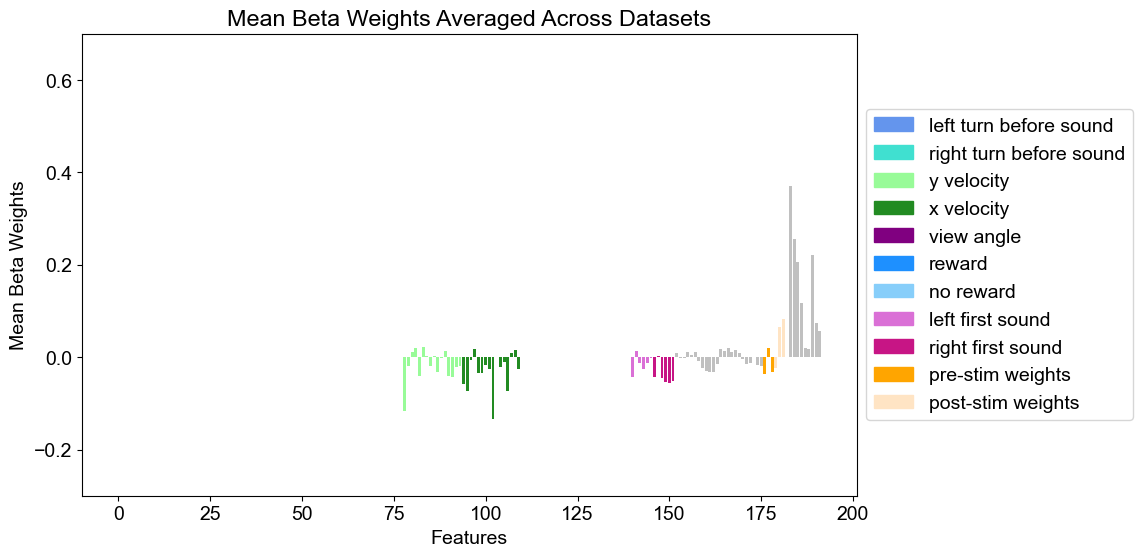

In [138]:
import matplotlib.pyplot as plt

significant_neurons = neurons_by_dataset 
# Placeholder for the highly modulated beta weights
highly_mod_betas = {}

# Placeholder for all beta weights across folds and datasets
all_betas = []

ex_model = results_pass

# Loop through the keys in ex_model and check for significant neurons
for key in significant_neurons.keys():
    if np.any(significant_neurons[key]):  # Only process if there are significant neurons
        betas_across_folds = []

        for fold in ex_model[key]['model_output_all'].keys():
            # Extract beta weights for significant neurons
            betas = ex_model[key]['model_output_all'][fold]['B_weights'][:, significant_neurons[key]]
            
            # Squeeze to remove unnecessary dimensions
            betas_squeezed = np.squeeze(betas)
            
            # If squeezing resulted in a 1D array, reshape it back to (192, 1)
            if betas_squeezed.ndim == 1:
                betas_squeezed = betas_squeezed.reshape(-1, 1)
            
            # Append to list of beta weights across folds
            betas_across_folds.append(betas_squeezed)

        # Stack beta weights across folds and compute the mean along the fold axis (axis=0)
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        highly_mod_betas[key] = mean_betas
        print(np.shape(highly_mod_betas[key]))

        

        # # Append mean beta weights to the all_betas list
        # all_betas.append(mean_betas)
        # print(np.shape(all_betas))
        
        #concatenate or stack here after taking mean across folds so that I end up with array that has all predictors (192) x all neurons
    # all_betas = np.vstack((mean_betas))
    
# Now we need to create the all_betas array in the desired shape (192, num_neurons)
# Using a list to collect all means
all_betas = []

for mean_betas in highly_mod_betas.values():
    all_betas.append(mean_betas)  # Collect mean_betas directly

# Convert to a NumPy array and stack along the first axis (predictors)
all_betas = np.concatenate(all_betas, axis=1)  # (192, num_neurons)

# Print the final shape
print(f"Final Shape of All Betas: {np.shape(all_betas)}")   



# Check and reshape arrays before stacking if necessary

reshaped_betas = all_betas
# Stack beta weights across datasets and compute the overall mean
all_mean_betas = np.mean(reshaped_betas,axis=1)

# Create a color array for the bars
# colors = ['blue' if i < 176 or i > 178 else 'red' for i in range(all_mean_betas.shape[0])]

# Create a color array for the bars
colors = []
for i in range(all_mean_betas.shape[0]):
    if 0 <= i <= 5: #2 <= i <= 5:
        colors.append('cornflowerblue')  # left turn right before sound
    # if 6 <= i <= 38:
    #     colors.append('lightsteelblue')  # Highlight for weights 3-6 %left turn right before sound
    elif 39 <= i <= 44: #41 <= i <= 44:
        colors.append('turquoise')  # right turn right before sound
    # elif 45 <= i <= 77:
    #     colors.append('paleturquoise')  # right turn right aftter sound
    elif 78 <= i <= 93:
        colors.append('palegreen') # y velocity
    elif 94 <= i <= 109:
        colors.append('forestgreen') # x velocity
    elif 110 <= i <= 121:
        colors.append('purple') # view angle
    elif 122 <= i <= 129:
        colors.append('dodgerblue')  # reward
    elif 130 <= i <= 139:
        colors.append('lightskyblue')  # no reward
    elif 140 <= i <= 145:
        colors.append('orchid') #-90 first sound
    elif 146 <= i <= 151:
        colors.append('mediumvioletred') #90 first sound
    elif 176 <= i <= 178:
        colors.append('orange')  # pre-stim weights
    elif 179 <= i <= 182:
        colors.append('bisque')  # post-stim weights
    else:
        colors.append('silver')  # Default color

legend_labels = [
    'left turn before sound',
    # 'left turn right before sound',
    'right turn before sound',
    # 'right turn right after sound',
    'y velocity',
    'x velocity',
    'view angle',
    'reward',
    'no reward',
    '-90 first sound',
    '90 first sound',
    'pre-stim weights',
    'post-stim weights'
]

# Plot the mean beta weights with highlighted specific weights
plt.figure(figsize=(10, 6))
# plt.bar(range(mean_weights.shape[0]), mean_weights # Use the color array for the bars

plt.bar(range(len(all_mean_betas)), all_mean_betas, color=colors) 
plt.xlabel('Features')
plt.ylabel('Mean Beta Weights')
plt.title('Mean Beta Weights Averaged Across Datasets')

# Create legend handles with the correct unique colors
unique_colors = {
    'cornflowerblue': 'left turn before sound',
    'turquoise': 'right turn before sound',
    'palegreen': 'y velocity',
    'forestgreen': 'x velocity',
    'purple': 'view angle',
    'dodgerblue': 'reward',
    'lightskyblue': 'no reward',
    'orchid': 'left first sound',
    'mediumvioletred': 'right first sound',
    'orange': 'pre-stim weights',
    'bisque': 'post-stim weights'
}

# Create legend with only the unique colors and their labels
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in unique_colors.keys()]
legend_labels = list(unique_colors.values())

plt.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)
plt.ylim(-.3, .7)

plt.show()



(192, 20)
(192, 11)
(192, 11)
(192, 11)
(192, 8)
(192, 3)
(192, 6)
(192, 19)
(192, 19)
(192, 16)
(192, 14)
(192, 14)
(192, 11)
(192, 17)
(192, 11)
(192, 5)
(192, 5)
(192, 4)
(192, 4)
(192, 16)
(192, 13)
(192, 17)
(192, 8)
(192, 17)
(192, 8)
Final Shape of All Betas: (192, 288)


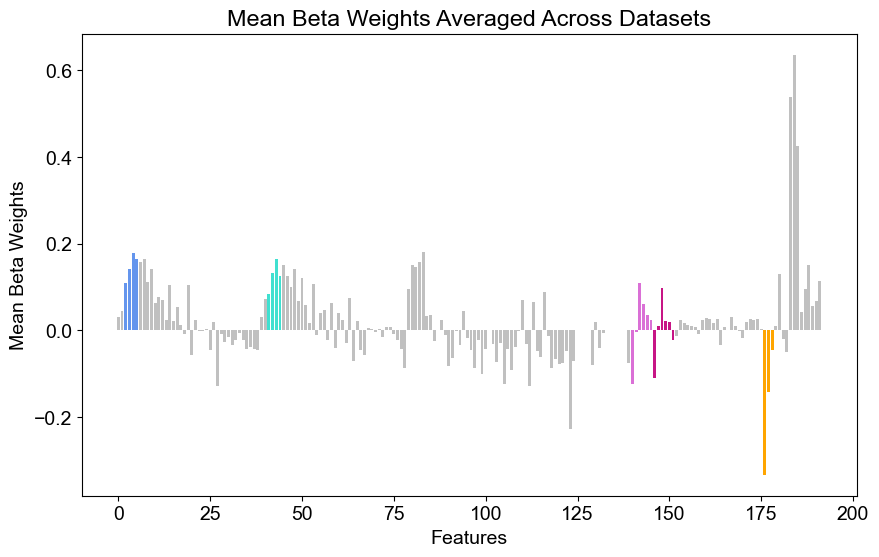

In [76]:
import matplotlib.pyplot as plt

significant_neurons = neurons_by_dataset 
# Placeholder for the highly modulated beta weights
highly_mod_betas = {}

# Placeholder for all beta weights across folds and datasets
all_betas = []

ex_model = results_pre

# Loop through the keys in ex_model and check for significant neurons
for key in significant_neurons.keys():
    if np.any(significant_neurons[key]):  # Only process if there are significant neurons
        betas_across_folds = []

        for fold in ex_model[key]['model_output_all'].keys():
            # Extract beta weights for significant neurons
            betas = ex_model[key]['model_output_all'][fold]['B_weights'][:, significant_neurons[key]]
            
            # Squeeze to remove unnecessary dimensions
            betas_squeezed = np.squeeze(betas)
            
            # If squeezing resulted in a 1D array, reshape it back to (192, 1)
            if betas_squeezed.ndim == 1:
                betas_squeezed = betas_squeezed.reshape(-1, 1)
            
            # Append to list of beta weights across folds
            betas_across_folds.append(betas_squeezed)

        # Stack beta weights across folds and compute the mean along the fold axis (axis=0)
        mean_betas = np.mean(np.stack(betas_across_folds, axis=0), axis=0)
        highly_mod_betas[key] = mean_betas
        print(np.shape(highly_mod_betas[key]))

        

        # # Append mean beta weights to the all_betas list
        # all_betas.append(mean_betas)
        # print(np.shape(all_betas))
        
        #concatenate or stack here after taking mean across folds so that I end up with array that has all predictors (192) x all neurons
    # all_betas = np.vstack((mean_betas))
    
# Now we need to create the all_betas array in the desired shape (192, num_neurons)
# Using a list to collect all means
all_betas = []

for mean_betas in highly_mod_betas.values():
    all_betas.append(mean_betas)  # Collect mean_betas directly

# Convert to a NumPy array and stack along the first axis (predictors)
all_betas = np.concatenate(all_betas, axis=1)  # (192, num_neurons)

# Print the final shape
print(f"Final Shape of All Betas: {np.shape(all_betas)}")   



# Check and reshape arrays before stacking if necessary

reshaped_betas = all_betas
# Stack beta weights across datasets and compute the overall mean
all_mean_betas = np.mean(reshaped_betas,axis=1)

# Create a color array for the bars
# colors = ['blue' if i < 176 or i > 178 else 'red' for i in range(all_mean_betas.shape[0])]

# Create a color array for the bars
colors = []
for i in range(all_mean_betas.shape[0]):
    if 2 <= i <= 5:
        colors.append('cornflowerblue')  # Highlight for weights 3-6 %left turn right before sound
    elif 41 <= i <= 44:
        colors.append('turquoise')  # right turn right before sound
    elif 140 <= i <= 145:
        colors.append('orchid') #-90 first sound
    elif 146 <= i <= 151:
        colors.append('mediumvioletred') #90 first sound
    elif 176 <= i <= 178:
        colors.append('orange')  # Highlight for weights 176-178
    else:
        colors.append('silver')  # Default color

# Plot the mean beta weights with highlighted specific weights
plt.figure(figsize=(10, 6))
# plt.bar(range(mean_weights.shape[0]), mean_weights # Use the color array for the bars

plt.bar(range(len(all_mean_betas)), all_mean_betas, color=colors) 
plt.xlabel('Features')
plt.ylabel('Mean Beta Weights')
plt.title('Mean Beta Weights Averaged Across Datasets')
plt.show()



-1.8201676484960113e+34
[-8.54189128e-03 -3.37634903e-03 -1.00352661e-03 -2.16850933e-03
 -6.25866252e-03 -1.61238508e-03 -3.03755043e-02 -5.50860475e-02
 -3.74833237e-01 -6.62662457e-04 -1.01801286e-02 -2.33490988e-03
 -2.15887822e-03 -1.77307043e-04 -9.14730991e-04 -3.42439973e-02
 -8.72014974e-04 -3.63435908e-03 -6.16618291e-03 -1.23056008e-02
 -8.68788306e-04 -2.80847277e-03 -1.60300595e-02 -4.65877062e-03
 -7.63261576e-03 -1.30278787e-03 -2.03162482e-02 -5.46670945e-03
 -3.19265216e-03 -8.39953530e-03 -6.60870448e-04 -2.67609965e-02
 -8.71456671e-03 -2.60148977e-02 -1.67755061e-02 -1.64944495e-02
 -1.13173200e-02 -7.33455615e-03 -8.46483497e-03 -4.48765076e-03
 -7.99755702e-04 -7.21357069e-03 -2.17936862e-03 -1.17343171e-03
 -5.57178623e-03 -3.74214582e-03 -9.16147681e-03 -1.82016765e+34
 -2.68988144e-03 -3.21575303e-02 -8.09107115e-03 -2.34965521e-03
 -6.22619016e-03 -1.21835193e-02 -2.59276062e-03 -2.67335341e-03
 -2.11689309e-04]


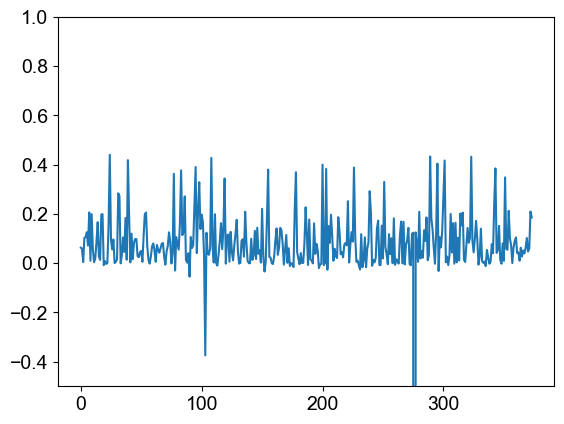

In [63]:
print(results_pre['HA11-1R_2023-05-02']['mean_dev'].min())
plt.plot(results_pre['HA11-1R_2023-05-02']['mean_dev'])
# fix y limits
plt.ylim(-0.5, 1)

print(results_pre['HA11-1R_2023-05-02']['mean_dev'][results_pre['HA11-1R_2023-05-02']['mean_dev'] < 0])

Found 1 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 2 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 2 outliers with values outside [-0.1, 1]
 model deviance explained: 0.105 ± 0.098
Found 2 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 2 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 1 outliers with values outside [-0.1, 1]
Found 3 outliers with values outside [-0.1, 1]
_behav model deviance explained: 0.075 ± 0.094


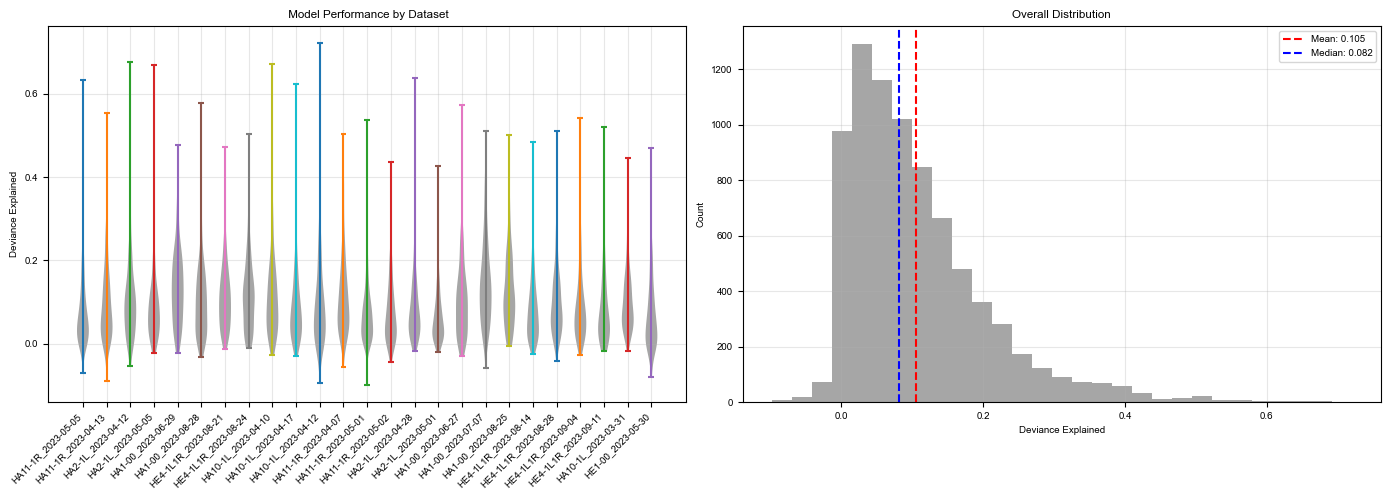

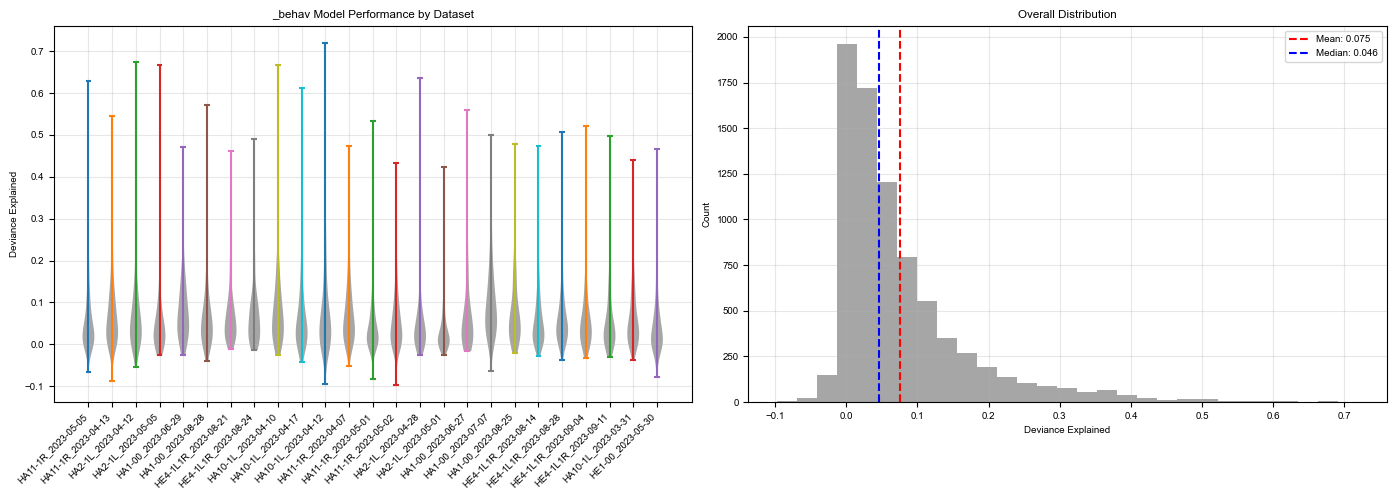

In [235]:
# Create output directory for supplemental figures
supp_figure_dir = f'{save_results}/glm_coupling/supplemental'
os.makedirs(supp_figure_dir, exist_ok=True)
import matplotlib.pyplot as plt


def clean_deviance_values(dev_values, lower_bound=-1, upper_bound=1):
    """Clean deviance explained values by removing extreme outliers."""
    cleaned_dev = np.array(dev_values, dtype=float)
    
    # Find extreme outliers
    outliers = np.where((cleaned_dev < lower_bound) | (cleaned_dev > upper_bound))[0]
    if len(outliers) > 0:
        print(f"Found {len(outliers)} outliers with values outside [{lower_bound}, {upper_bound}]")
        cleaned_dev[outliers] = np.nan
    
    return cleaned_dev

def plot_deviance_summary(results_pre, model_type='behav', save_path=None, 
                         lower_bound=-.2, upper_bound=1):
    """Plot deviance explained summary across datasets."""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Collect deviance explained for all datasets
    dataset_dev = []
    dataset_labels = []
    all_dev = []
    
    for dataset in results_pre.keys():
        dev_key = f'mean_dev{model_type}'
        # Clean deviance values
        dev_explained = clean_deviance_values(
            results_pre[dataset][dev_key],
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        all_dev.extend(dev_explained[~np.isnan(dev_explained)])
        
        dataset_dev.append(np.nanmean(dev_explained))
        dataset_labels.append(dataset)
        
        # Plot distribution for each dataset
        valid_dev = dev_explained[~np.isnan(dev_explained)]
        violin = ax1.violinplot(valid_dev, positions=[len(dataset_dev)-1])
        for pc in violin['bodies']:
            pc.set_facecolor('gray')
            pc.set_alpha(0.7)
    
    # Customize dataset distribution plot
    ax1.set_xticks(range(len(dataset_labels)))
    ax1.set_xticklabels(dataset_labels, rotation=45, ha='right')
    ax1.set_ylabel('Deviance Explained')
    ax1.set_title(f'{model_type.capitalize()} Model Performance by Dataset')
    ax1.grid(True, alpha=0.3)
    
    # Plot overall distribution
    bins = np.linspace(np.nanmin(all_dev), np.nanmax(all_dev), 30)
    ax2.hist(all_dev, bins=bins, color='gray', alpha=0.7)
    ax2.axvline(np.nanmean(all_dev), color='r', linestyle='--', 
                label=f'Mean: {np.nanmean(all_dev):.3f}')
    ax2.axvline(np.nanmedian(all_dev), color='b', linestyle='--', 
                label=f'Median: {np.nanmedian(all_dev):.3f}')
    ax2.set_xlabel('Deviance Explained')
    ax2.set_ylabel('Count')
    ax2.set_title('Overall Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    return np.nanmean(all_dev), np.nanstd(all_dev)

# Usage remains the same
model_types = ['','_behav']
dev_stats = {}

for model in model_types:
    mean_dev, std_dev = plot_deviance_summary(
        results_pre,
        model_type=model,
        save_path=f'{supp_figure_dir}/deviance_explained_{model}.pdf',
        lower_bound=-.1,  # Adjust these bounds as needed
        upper_bound=1
    )
    dev_stats[model] = {'mean': mean_dev, 'std': std_dev}
    print(f"{model.capitalize()} model deviance explained: {mean_dev:.3f} ± {std_dev:.3f}")


def plot_deviance_summary_single_plot(results_pre, model_type='behav', save_path=None, 
                         lower_bound=-.2, upper_bound=1, figsize=(14, 5), bins = 30, ylims=(0,50), label_names=True, color_hist = 'gray',ax2=None):
    """Plot deviance explained summary across datasets."""
    if ax2 is None:
        fig, (ax2) = plt.subplots(1, figsize=figsize)
    # Set global font size and family 
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})
    
    # Collect deviance explained for all datasets
    dataset_dev = []
    dataset_labels = []
    all_dev = []
    
    for dataset in results_pre.keys():
        dev_key = f'mean_dev{model_type}'
        # Clean deviance values
        dev_explained = clean_deviance_values(
            results_pre[dataset][dev_key],
            lower_bound=lower_bound,
            upper_bound=upper_bound
        )
        all_dev.extend(dev_explained[~np.isnan(dev_explained)])
        
        dataset_dev.append(np.nanmean(dev_explained))
        dataset_labels.append(dataset)
        
    
    # Plot overall distribution
    bins = np.linspace(np.nanmin(all_dev), np.nanmax(all_dev), bins)
    # ax2.hist(all_dev, bins=bins, color='gray', alpha=0.7)
    # Plot overall distribution as percentage histogram
    counts, bins = np.histogram(all_dev, bins= bins)  # raw counts
    percentages = counts / len(all_dev) * 100      # convert to %

    ax2.bar(bins[:-1], percentages, width=np.diff(bins),
            color= color_hist, alpha=0.7, align='edge')
    
    default_color_mean = 'black' #'orangered'
    default_color_median = 'orangered' ##'mediumblue'
    ax2.axvline(np.nanmean(all_dev), color=default_color_mean, linestyle='--', 
                label=f'Mean: {np.nanmean(all_dev):.3f}')
    ax2.axvline(np.nanmedian(all_dev), color=default_color_median, linestyle='--', 
                label=f'Median: {np.nanmedian(all_dev):.3f}')
    if label_names:
        ax2.set_xlabel('Deviance Explained')
        ax2.set_ylabel("Probability (%)")
    # ax2.set_ylabel('Count')
    # Update y-axis to percentage
    # ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))


    # ax2.set_title('Overall Distribution')
    # ax2.legend(loc = 'upper right', fontsize=6) #loc='center left', bbox_to_anchor=(1, 0.5)
    ax2.legend(
        loc="upper right",
        bbox_to_anchor=(1.5, 1),  # push legend to the right
        fontsize=6,
        frameon=False
    )

    # ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6) #loc='center left', bbox_to_anchor=(1, 0.5)
    # ax2.grid(True, alpha=0.3)

    if ylims:
        ax2.set_ylim(ylims)
    xlims = (-.1,.5)
    ax2.set_xlim(xlims)

    for spine in ["top", "right"]:
        ax2.spines[spine].set_visible(False)

    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    
    return np.nanmean(all_dev), np.nanstd(all_dev)

# # Usage remains the same
# model_types = ['','_behav']
# dev_stats = {}

# for model in model_types:
#     mean_dev, std_dev = plot_deviance_summary(
#         results_pre,
#         model_type=model,
#         save_path=f'{supp_figure_dir}/deviance_explained_{model}.pdf',
#         lower_bound=-.1,  # Adjust these bounds as needed
#         upper_bound=1
#     )
#     dev_stats[model] = {'mean': mean_dev, 'std': std_dev}
#     print(f"{model.capitalize()} model deviance explained: {mean_dev:.3f} ± {std_dev:.3f}")

In [34]:
plotter.default_colors_model_type = {
    'full': 'deepskyblue',
    'behav':  'mediumvioletred'} #cornflowerblue #palevioletred

Found 27 outliers with values outside [0, 1]
Found 23 outliers with values outside [0, 1]
Found 17 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 5 outliers with values outside [0, 1]
Found 6 outliers with values outside [0, 1]
Found 5 outliers with values outside [0, 1]
Found 8 outliers with values outside [0, 1]
Found 18 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 28 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 33 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 12 outliers with values outside [0, 1]
Found 10 outliers with values outside [0, 1]
Found 3 outliers with values outside [0, 1]
Found 4 outliers with values outside [0, 1]
Found 23 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 16 outlier

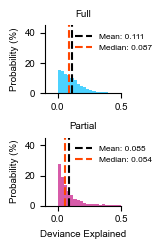

In [302]:
fig, axes = plt.subplots(2, 1, figsize=(1.85, 1.25*2))  # 1 row, 2 cols original figsize=(1.85,1.25)
model_type_labels = ['Full', 'Partial']
for i, model in enumerate(model_types):
    model_key = model.lstrip('_') if model else 'full'
    ax = axes[i]
    
    mean_dev, std_dev = plot_deviance_summary_single_plot(
        results_pre,
        model_type=model,
        ax2=ax,  # pass the subplot axis
        lower_bound=0,
        upper_bound=1,
        figsize=None,  # figsize handled by the figure
        bins=30,
        ylims=(0, 45),
        label_names=False,
        color_hist=plotter.default_colors_model_type[model_key],
    )
    ax.set_title(model_type_labels[i].capitalize(),fontsize = 7)  # optional title per subplot

axes[1].set_xlabel('Deviance Explained')  # Set x-label only for the bottom plot
axes[0].set_ylabel('Probability (%)')  # Set y-label only for the top
axes[1].set_ylabel('Probability (%)')  # Set y-label only for the top
plt.tight_layout()

save_path = f'{supp_figure_dir}/deviance_explained_hist_pre_combined.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)

Found 27 outliers with values outside [0, 1]
Found 23 outliers with values outside [0, 1]
Found 17 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 5 outliers with values outside [0, 1]
Found 6 outliers with values outside [0, 1]
Found 5 outliers with values outside [0, 1]
Found 8 outliers with values outside [0, 1]
Found 18 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 28 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 33 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 12 outliers with values outside [0, 1]
Found 10 outliers with values outside [0, 1]
Found 3 outliers with values outside [0, 1]
Found 4 outliers with values outside [0, 1]
Found 23 outliers with values outside [0, 1]
Found 13 outliers with values outside [0, 1]
Found 14 outliers with values outside [0, 1]
Found 16 outlier

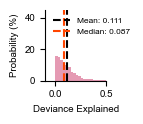

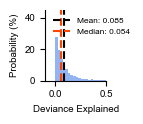

In [230]:
# Usage remains the same
model_types = ['','_behav']
dev_stats = {}

for model in model_types:
    model_key = model.lstrip('_') if model else 'full'
    mean_dev, std_dev = plot_deviance_summary_single_plot(
        results_pre,
        model_type=model,
        save_path=f'{supp_figure_dir}/deviance_explained_hist_updated_{model}_pre.pdf',
        lower_bound=0,  # Adjust these bounds as needed
        upper_bound=1,
        figsize=(1.85,1.25), #(2,1.5)
        bins = 30,
        ylims = (0,45),
        label_names = True,
        color_hist = plotter.default_colors_model_type[model_key]
    )
    dev_stats[model] = {'mean': mean_dev, 'std': std_dev}
    print(f"{model.capitalize()} model deviance explained: {mean_dev:.3f} ± {std_dev:.3f}")

NameError: name 'patches' is not defined

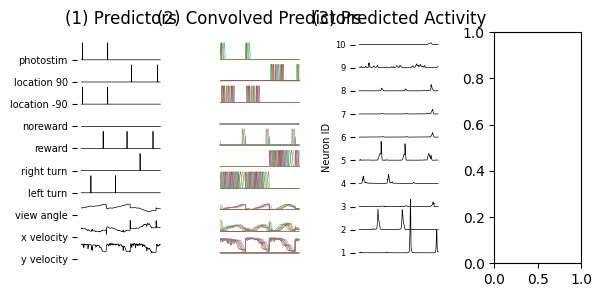

In [70]:
#create functions to generate supplemental figure 2 panels
import os
import numpy as np
import scipy.io
import h5py
import matplotlib.pyplot as plt
def load_decoder_and_glm_variables(mouse_dates_keys, session_idx, model_type, fold_number, frames, decoder_type = 'choice', shuffle_num = 0):
    example_dataset = [mouse_dates_keys[session_idx]]
    animalID, date = example_dataset[0].split('_')
    save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_{model_type}/'
    path = os.path.join(save_directory, f"prepost trial cv 73 #{fold_number+1}/test") #get testing folder

    # Load behavioral matrices
    behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
    behav_matrix = behav['behav_the_matrix']
    behav_ids = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix_ids.mat'))
    behav_matrix_ids_raw = behav_ids['behav_the_matrix_ids'][0]

    behav = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
    behav_big_matrix = behav['behav_big_matrix']
    behav_big_ids = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix_ids.mat'))
    behav_big_matrix_ids = behav_big_ids['behav_big_matrix_ids'][0]

    # Load condition array trials and frames
    condition_array = scipy.io.loadmat(os.path.join(path, 'condition_array_trials.mat'))
    condition_array_trials = condition_array['condition_array_trials']
    combined_frames = scipy.io.loadmat(os.path.join(path, 'combined_frames_included.mat'))
    combined_frames_included = combined_frames['combined_frames_included'].squeeze()

    # Load decoder
    decoder_path = os.path.join(save_directory, f"decoding/{fold_number+1}_1/decoder_results_regular_{decoder_type}.mat")
    with h5py.File(decoder_path, 'r') as f:
        decoder = f['decoder_results']
        decoder_group = decoder['inputs'][decoder_type]
        decoder_info = decoder['aligned'][decoder_type]

        i = shuffle_num  # shuffle_num - 1
        #get shuffle i
        pop_ref = decoder_group['pop_instantaneous_decoded_variables'][i, 0]
        sc_ref = decoder_group['sc_instantaneous_decoded_variables'][i, 0]
        pop_ref_cumulative = decoder_group['pop_cumulative_decoded_variables'][i, 0]
        sc_ref_cumulative = decoder_group['sc_cumulative_decoded_variables'][i, 0]
        decoder_info_ref = decoder_info['results'][i, 0]

        decoder_info_group = f[decoder_info_ref]
        info_data = decoder_info_group['sc_instantaneous_information'][()]
        info_data_cumulative = decoder_info_group['sc_cumulative_information'][()]
        testing_trials_used = decoder_info_group['alignment']['trials_used']['test'][()] #decoder uses data only form testing folder
        testing_trials_used = np.where(testing_trials_used)[0]
            # Access the actual data
        decoder_population = f[pop_ref][()]
        decoder_singlecell = f[sc_ref][()]
        decoder_population_cumulative = f[pop_ref_cumulative][()]
        decoder_singlecell_cumulative = f[sc_ref_cumulative][()]

    return {
        'frames': frames,
        'behav_matrix': behav_matrix,
        'behav_matrix_ids_raw': behav_matrix_ids_raw,
        'behav_big_matrix': behav_big_matrix,
        'behav_big_matrix_ids': behav_big_matrix_ids,
        'condition_array_trials': condition_array_trials,
        'combined_frames_included': combined_frames_included,
        'info_data': info_data,
        'info_data_cumulative': info_data_cumulative,
        'testing_trials_used': testing_trials_used,
        'decoder_population': decoder_population,
        'decoder_singlecell': decoder_singlecell,
        'decoder_population_cumulative': decoder_population_cumulative,
        'decoder_singlecell_cumulative': decoder_singlecell_cumulative,
        'example_dataset': example_dataset,
        'save_directory': save_directory,
        'fold_number': fold_number
    }

def get_sorted_neuron_indices(info_data):
    #sort neurons by max information value
    max_per_neuron = np.max(info_data, axis=0)
    sorted_idx = np.argsort(max_per_neuron)[::-1]
    return sorted_idx

def get_highlight_trial_indices(trials_included, testing_trials_used):
    """
    Returns the indices and values of trials_included that are also in testing_trials_used.
    """
    mask = np.isin(trials_included, testing_trials_used)
    highlight_indices = np.where(mask)[0]
    highlight_values = trials_included[highlight_indices]
    return highlight_indices, highlight_values

# def plot_scale_bar(scalebar_length, scalebar_start, ax, scalebar_color='black', scalebar_linewidth=1, frame_rate = 30):
#     """
#     Plots a scale bar on the given axis.

#     Parameters:
#     scalebar_length: length of the scale bar in frames
#     scalebar_start: starting x position of the scale bar
#     ax: matplotlib axis to plot on
#     scalebar_color: color of the scale bar
#     """
#     scalebar_end = scalebar_start + scalebar_length
    
#     ylims = ax.get_ylim()
#     y_range = ylims[1] - ylims[0]
    
#     # place scalebar just below traces (5% of axis range)
#     y_pos = ylims[0] - 0.05 * y_range  
    
#     ax.plot([scalebar_start, scalebar_end],
#             [y_pos, y_pos],
#             color=scalebar_color,
#             linewidth=scalebar_linewidth)

#     # optional label under scalebar
#     ax.text((scalebar_start + scalebar_end) / 2,
#             y_pos - 0.02 * y_range,
#             f"{scalebar_length/frame_rate:.0f} sec",
#             ha='center', va='top', fontsize=6)
def plot_scale_bar(scalebar_length, scalebar_start, ax, 
                   scalebar_color='black', scalebar_linewidth=1, frame_rate=30, xticks=None):
    """
    Plots a scale bar on the given axis without changing y-limits.
    Draws in axis coordinates so it sits below the data.
    """
    # transform scalebar x from data, y from axes
    trans = ax.get_xaxis_transform()  # x in data coords, y in axes coords
    
    # x positions in data coords
    scalebar_end = scalebar_start + scalebar_length

    # y position in axes coords (e.g., -0.08 below the x-axis)
    if xticks is not None:
        y_pos = -0.1  
        ypos_mins = 0.03
    else:
        y_pos = +0.01  
        ypos_mins = 0.02

    # plot scalebar
    ax.plot([scalebar_start, scalebar_end],
            [y_pos, y_pos],
            transform=trans,
            color=scalebar_color,
            linewidth=scalebar_linewidth,
            clip_on=False)  # so it's visible outside axes

    # label
    ax.text((scalebar_start + scalebar_end) / 2,
            y_pos - ypos_mins,   # further down a bit
            f"{scalebar_length/frame_rate:.0f} sec",
            ha='center', va='top', fontsize=6,
            transform=trans,
            clip_on=False)

def plot_glm_predictors_and_decoder(variables, sorted_idx, results_pre, do_highlight_trial=None, save_path=None, figsize = (6, 10 * 0.3), number_subplots = 4, norm_y_pred = False, subplot_4_type = 'traces'):
    frames = variables['frames']
    behav_matrix = variables['behav_matrix']
    behav_matrix_ids_raw = variables['behav_matrix_ids_raw']
    behav_big_matrix = variables['behav_big_matrix']
    behav_big_matrix_ids = variables['behav_big_matrix_ids']
    info_data = variables['info_data']
    decoder_singlecell = variables['decoder_singlecell']
    testing_trials_used = variables['testing_trials_used']
    condition_array_trials = variables['condition_array_trials']
    combined_frames_included = variables['combined_frames_included']
    example_dataset = variables['example_dataset']
    fold_number = variables['fold_number']
    model_output_behav = results_pre[example_dataset[0]]['model_output_behav']
    y_pred_model = model_output_behav[fold_number]['y_pred'][frames, :] #frames x Neurons

    # Clean and deduplicate variable names
    flat_ids = [str(var[0]) if isinstance(var, np.ndarray) else str(var) for var in behav_matrix_ids_raw]
    clean_ids = [v.replace('upcoming ', '') for v in flat_ids]
    unique_names = {}
    for idx, name in enumerate(clean_ids):
        if name not in unique_names:
            unique_names[name] = idx
    deduped_names = list(unique_names.keys())
    deduped_indices = list(unique_names.values())

    # Normalize original behavioral matrix
    normalized_matrix = np.zeros_like(behav_matrix, dtype=float)
    for i in range(behav_matrix.shape[0]):
        row = behav_matrix[i]
        min_val = np.min(row)
        max_val = np.max(row)
        normalized_matrix[i] = (row - min_val) / (max_val - min_val) if max_val - min_val != 0 else 0

    # Determine trials included from condition array and frames
    
    _, trials_included, relative_trial_starts = get_testing_trial_frames(combined_frames_included, frames, condition_array_trials)

    # Determine trials to highlight
    highlight_indices, _ = get_highlight_trial_indices(trials_included, testing_trials_used)

    # Plotting
    fig, axs = plt.subplots(1, number_subplots, figsize=figsize, sharex=False,gridspec_kw={'width_ratios': [1,1,1,1],'height_ratios': [1],'wspace': .6}) #(6, len(deduped_names) * 0.3)
    offset = 1.3

    # (1) Predictors
    for i, idx in enumerate(deduped_indices):
        axs[0].plot(np.array(frames), normalized_matrix[idx, frames] + i * offset, color='black', linewidth=0.5)
    axs[0].set_yticks(np.arange(len(deduped_names)) * offset)
    axs[0].set_yticklabels(deduped_names, fontsize=7)
    axs[0].set_title("(1) Predictors")
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    axs[0].spines['bottom'].set_visible(False)
    axs[0].spines['left'].set_visible(False)
    axs[0].set_xticks([])
    axs[0].set_xticklabels([])

    # (2) Convolved Predictors
    for i, name in enumerate(deduped_names):
        matches = [j for j, bigname in enumerate(behav_big_matrix_ids) if name in str(bigname[0])]
        for k, idx in enumerate(matches[:]): #matches[:5] to plot 5 convolutions
            axs[1].plot(np.array(frames), behav_big_matrix[idx, frames] + i * offset, alpha=1, linewidth=0.3)
    axs[1].set_yticks(np.arange(len(deduped_names)) * offset)
    axs[1].set_yticklabels([])
    axs[1].set_title("(2) Convolved Predictors")
    axs[1].spines['top'].set_visible(False)
    axs[1].spines['right'].set_visible(False)
    axs[1].spines['bottom'].set_visible(False)
    axs[1].spines['left'].set_visible(False)
    axs[1].set_xticks([])
    axs[1].set_yticks([])
    axs[1].set_xticklabels([])

    # (3) Example predicted weights for multiple neurons (dummy example)
    offset_trace = 0.25 # vertical spacing between neurons
    if norm_y_pred:
        offset_trace = 1.5 # vertical spacing between neurons
    n_neurons = 10
    for i in range(n_neurons):
        trace = y_pred_model[:, sorted_idx[i]]
        if norm_y_pred:
            trace = (trace - np.min(trace)) / (np.max(trace) - np.min(trace))  # Normalize to [0, 1]
        axs[2].plot(np.array(frames), trace + i * offset_trace, linewidth=0.5, color='black')

    axs[2].set_title("(3) Predicted Activity")
    axs[2].set_xticks([])
    axs[2].set_yticks(np.arange(n_neurons) * offset_trace)
    axs[2].set_yticklabels([str(i + 1) for i in range(n_neurons)], fontsize=6)
    axs[2].set_ylabel("Neuron ID", fontsize=7, rotation=90, labelpad=2)
    axs[2].set_xticklabels([])
    axs[2].spines['top'].set_visible(False)
    axs[2].spines['right'].set_visible(False)
    axs[2].spines['bottom'].set_visible(False)
    axs[2].spines['left'].set_visible(False)

    #add optional rectangle to highlight trial
    highlight_trial = highlight_indices # set to None if no highlight desired

    for ax in axs[:do_highlight_trial]:
        if highlight_trial.size > 0:
            # trial indices are 1-based in your description
            trial_idx = highlight_trial[0] - 1  
            x_start = relative_trial_starts[trial_idx] + frames[0]  # adjust for actual frame indices
            if trial_idx < len(relative_trial_starts) - 1:
                x_end = relative_trial_starts[trial_idx + 1] - 1 + frames[0]  # adjust for actual frame indices
            else:
                x_end = frames[-1]  # until end of data

            ylims = ax.get_ylim()#axs[2].get_ylim()
            # rectangle spans full y-limits
            rect = patches.Rectangle((x_start, ylims[0]),
                                        x_end - x_start,
                                        ylims[1] - ylims[0],
                                        linewidth=0,
                                        facecolor="gray",
                                        alpha=0.1,
                                        zorder=-1)  # send behind traces
            ax.add_patch(rect)

    ref_pos = axs[0].get_position()
    #add scale bars
    scalebar_length = 30 *5  # in frames(5 seconds at 30 fps)
    scalebar_linewidth = 1.5
    scalebar_start = frames[0] + 10  # small offset from left edge
    for ax in axs[:3]:  # add to first three subplots
        plot_scale_bar(scalebar_length, scalebar_start, ax, scalebar_color='black', scalebar_linewidth=scalebar_linewidth , frame_rate = 30)
    
    # (4) Decoder
    offset_decoder = 1.5
    trial_id = np.where(np.isin(testing_trials_used,trials_included))[0]  # Example, adjust as needed
    if trial_id.size > 0 and number_subplots == 4:
        if subplot_4_type == 'traces':
            for i in range(n_neurons):
                axs[3].plot(np.arange(decoder_singlecell.shape[0]),decoder_singlecell[:, trial_id, sorted_idx[i]] + i * offset_decoder, linewidth=0.5, color='black')

            event_frames = [6, 38, 70, 131, 145]
            event_labels = ['S1', 'S2', 'S3', 'T', 'R']
            for frame, event_label in zip(event_frames, event_labels):
                axs[3].axvline(x=frame, color='gray', linestyle=(0, (10, 5)), alpha=0.7, linewidth=0.3)

            axs[3].set_title('(4) Bayesian Decoder\n(Example Trial)')
            neuron_start_id = 1  # since you’re plotting i+200
            axs[3].set_yticks(np.arange(n_neurons) * offset_decoder ) #*1.15
            axs[3].set_yticklabels([str(i + neuron_start_id) for i in range(n_neurons)], fontsize=6)
            axs[3].set_ylabel("Neuron ID", fontsize=7, rotation=90, labelpad=2)  # <-- adds the extra label
            axs[3].set_xticklabels([])
            axs[3].spines['top'].set_visible(False)
            axs[3].spines['right'].set_visible(False)
            axs[3].spines['bottom'].set_visible(False)
            axs[3].spines['left'].set_visible(False)
            axs[3].set_xticks(event_frames)
            axs[3].set_xticklabels(event_labels, fontsize=6)
            # # Get reference box from subplot 0 (or any other)
            axs[3].set_xlim([0,decoder_singlecell.shape[0]])
            
            pos3 = axs[3].get_position()
            # axs[3].set_position([pos3.x0, ref_pos.y0+0.05, ref_pos.width, ref_pos.height-.05])
            axs[3].set_position([pos3.x0, ref_pos.y0+0.05, ref_pos.width, ref_pos.height-0.05])
            # axs[3].set_position(axs[2].get_position())  # match position of subplot 2
            scalebar_length = 30  # in frames(5 seconds at 30 fps)
            scalebar_linewidth = 1.5
            scalebar_start = 1  # small offset from left edge
            plot_scale_bar(scalebar_length, scalebar_start, axs[3], scalebar_color='black', scalebar_linewidth=scalebar_linewidth , frame_rate = 30, xticks=event_frames)
    
        elif subplot_4_type == 'heatmap':
            # Plot heatmap of decoder activity for all trials
            decoded_per_trial = []
            neuron_start_id = 1
            for i in range(n_neurons):
                trial_data = decoder_singlecell[:, trial_id, sorted_idx[i]]  # shape: (frames, trials, neurons)
                trial_value = (trial_data.mean(axis=0) > 0.5).astype(int)
                decoded_per_trial.append(trial_value)
            im = axs[3].imshow(decoded_per_trial, aspect='auto', cmap='binary', interpolation='nearest')
            axs[3].set_title('(4) Bayesian Decoder\n(Example Trial)')
            axs[3].set_yticks(np.arange(n_neurons)) 
            axs[3].set_yticklabels([str(i + neuron_start_id) for i in range(n_neurons)], fontsize=6)
            axs[3].set_xticklabels([])
            axs[3].set_xticks([])
            axs[3].set_ylabel("Neuron ID", fontsize=7, rotation=90, labelpad=2)  # <-- adds the extra label

    # Save or show
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    # plt.show()

def get_testing_trial_frames(combined_frames_included, frames, condition_array_trials):
    """
    Extracting trial/frame relationships from imaging test trials.
    Parameters
    ----------
    combined_frames_included : np.ndarray
        Array containing all possible frame indices.
    frames : array-like
        Indices to select from combined_frames_included.
    condition_array_trials : np.ndarray
        2D array where the 5th column (index 4 in Python) holds frame IDs.
    Returns
    -------
    frame_relative_to_all : np.ndarray
        Subset of combined_frames_included corresponding to the selected frames.
    trials_included : np.ndarray
        Indices (0-based) of trials in condition_array_trials that match frame_relative_to_all.
    relative_trial_starts : np.ndarray
        Indices (0-based) of frames in frame_relative_to_all that match condition_array_trials[:, 4].
    """
    # Subset frames from combined_frames_included
    frame_relative_to_all = combined_frames_included[frames]

    # Find which trials (rows) in condition_array_trials[:, 4] are in frame_relative_to_all
    trials_included = np.where(np.isin(condition_array_trials[:, 4], frame_relative_to_all))[0]

    # Find which indices in frame_relative_to_all are present in condition_array_trials[:, 4]
    relative_trial_starts = np.where(np.isin(frame_relative_to_all, condition_array_trials[:, 4]))[0]

    return frame_relative_to_all, trials_included, relative_trial_starts



# Example usage:
variables = load_decoder_and_glm_variables(mouse_dates_keys, session_idx=2, model_type='pre', fold_number=0, frames=range(6000-9,6600-9)) 
sorted_idx = get_sorted_neuron_indices(variables['info_data'])
plot_glm_predictors_and_decoder(variables, sorted_idx, results_pre, save_path=None, number_subplots = 4, figsize = (6.5,10*.3), subplot_4_type = 'traces') #f"{plotter.save_results}/ex_predictors_wneurons_{variables['example_dataset']}_fold{variables['fold_number']}.pdf"


In [84]:
#find stimulus repeats onsets
stimulus_repeats_onsets = np.where(variables['behav_matrix'][7:8,:]>0)[1]
print(stimulus_repeats_onsets)

[  11  231  412  601  811 1012 1214 1459 1724 1919 2103 2296 2489 2697
 2895 3086 3294 3497 3740 3949 4179 4380 4578 4773 5007 5206 5404 5605
 5805 6000 6191]


In [88]:
def align_behavior_matrix(behav_matrix, condition_array_trials, combined_frames_included, alternative_alignment=False):
    # Align behav_matrix to combined_frames_included
    # Subset frames from combined_frames_included
    frame_relative_to_all = combined_frames_included

    # Find which trials (rows) in condition_array_trials[:, 4] are in frame_relative_to_all
    trials_included = np.where(np.isin(condition_array_trials[:, 4], frame_relative_to_all))[0]

    # Find which indices in frame_relative_to_all are present in condition_array_trials[:, 4]
    relative_trial_starts = np.where(np.isin(frame_relative_to_all, condition_array_trials[:, 4]))[0]-1 # -1 python indexing

    #find stimulus repeats onsets
    stimulus_repeats_onsets = np.where(variables['behav_matrix'][7:8,:]>0)[1]
    
    print(stimulus_repeats_onsets)

    # Event alignment
    alignment_frames = np.zeros((6, len(relative_trial_starts)))  # 6 events, len(good_trials) trials
    left_padding = {}
    right_padding = {}
    align_info = {}

    for event in range(4):
        if event == 0:
            alignment_frames[event, :] = stimulus_repeats_onsets  # Use the entire array for event 0
            left_padding[event] = 6
            right_padding[event] = 30

        elif event in [1, 2]:
            if len(stimulus_repeats_onsets) > event:
                alignment_frames[event, :] = stimulus_repeats_onsets[event:]  # Use a slice starting from the event index
            else:
                alignment_frames[event, :] = np.nan  # Fill with NaN if the index is out of bounds
            left_padding[event] = 1
            right_padding[event] = 30

        elif event == 3:
            alignment_frames[event, :] = np.where(variables['behav_matrix'][3:4, :] > 0)[0]  # Use the first dimension
            left_padding[event] = 30 if not alternative_alignment else 90
            right_padding[event] = 12 if not alternative_alignment else 60


        # elif event == 4:
        #     if all(len(onset) == 0 for onset in reward_onset):
        #         alignment_frames[event,:] = pure_onsets
        #         left_padding[event] = 1 if not alternative_alignment else 60
        #         right_padding[event] = max_length_reward - 1
        #     else:
        #         alignment_frames[event,:] = [None] * len(good_trials)
        #         for i in reward_trial:
        #             alignment_frames[event,i] = reward_onset[i][0]
        #         incorrect_trials = set(range(len(good_trials))) - set(reward_trial)
        #         for i in incorrect_trials:
        #             alignment_frames[event,i] = pure_onsets[i]
        #         left_padding[event] = 1
        #         right_padding[event] = 23

        # elif event == 5:
        #     alignment_frames[event,:] = [trial['iti_frames'][0][0] for trial in imaging_array]
        #     left_padding[event] = 1
        #     right_padding[event] = 80

    align_info['alignment_frames'] = alignment_frames
    align_info['left_padding'] = left_padding
    align_info['right_padding'] = right_padding

    return align_info, alignment_frames, left_padding, right_padding
    
    return aligned_behav_matrix, aligned_behav_big_matrix
[align_info, alignment_frames, left_padding, right_padding] = align_behavior_matrix(variables['behav_matrix'], variables['condition_array_trials'], variables['combined_frames_included'], alternative_alignment=False)

[  11  231  412  601  811 1012 1214 1459 1724 1919 2103 2296 2489 2697
 2895 3086 3294 3497 3740 3949 4179 4380 4578 4773 5007 5206 5404 5605
 5805 6000 6191]


ValueError: could not broadcast input array from shape (31,) into shape (60,)

V:/Connie/ProcessedData/HA2-1L/2023-04-12/GLM_3nmf_pre/prepost trial cv 73 #1/test
[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93] y velocity
[94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109] x velocity
[110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121] view angle
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38] left turn
[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77] right turn
[122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139] reward
[130, 131, 132, 133, 134, 135, 136, 137, 138, 139] noreward
[140, 141, 142, 143, 144, 145, 152, 153, 154, 155, 156, 157, 164, 165, 166, 167, 168, 169] location -90
[146, 147, 148, 149, 150, 151, 158, 159, 160, 161, 162, 163, 170, 171, 172, 173, 174, 175] locat

c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\numpy\core\fromnumeric.py:43: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = getattr(asarray(obj), method)(*args, **kwds)
c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\numpy\core\fromnumeric.py:43: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  result = getattr(asarray(obj), method)(*args, **kwds)
c:\Users\runyan1\AppData\Local\anaconda3\envs\Python_GLM\Lib\site-packages\numpy\core\fromnumeric.py:43: VisibleDeprecationWarning: Creating an nd

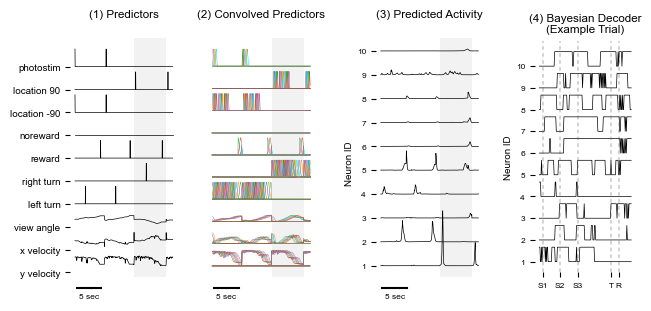

In [588]:
import scipy
import os
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

example_dataset = [mouse_dates_keys[2]]  # e.g., ['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')
model_type = 'pre'
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_{model_type}/'
fold_number = 0
traces_or_heatmap = 'traces'  # 'traces' or 'heatmap'

frames = range(6000,6600) #(5990,6150)
path = os.path.join(save_directory, f"prepost trial cv 73 #{fold_number+1}/test")
print(path)

# Load raw behavioral matrix
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix']
behav_ids = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix_ids.mat'))
behav_matrix_ids_raw = behav_ids['behav_the_matrix_ids'][0]

# Load convolved behavioral matrix
behav = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
behav_big_matrix = behav['behav_big_matrix']

behav_big_ids = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix_ids.mat'))
behav_big_matrix_ids = behav_big_ids['behav_big_matrix_ids'][0]

# Load condition array trials (to get trial/frame relationships)
condition_array = scipy.io.loadmat(os.path.join(path, 'condition_array_trials.mat'))
condition_array_trials = condition_array['condition_array_trials']
# Load combined frames included
combined_frames = scipy.io.loadmat(os.path.join(path, 'combined_frames_included.mat'))  
combined_frames_included = combined_frames['combined_frames_included'].squeeze()

#load example decoder?
decoder_path = os.path.join(save_directory, f"decoding/{fold_number+1}_1/decoder_results_regular_choice.mat")
shuffle_num = 1  # MATLAB-style index
i = shuffle_num - 1  # Python index

with h5py.File(decoder_path, 'r') as f:
    decoder = f['decoder_results']
    choice_group = decoder['inputs']['choice']
    choice_info = decoder['aligned']['choice']

    # Dereference object references
    pop_ref = choice_group['pop_instantaneous_decoded_variables'][i, 0]
    sc_ref = choice_group['sc_instantaneous_decoded_variables'][i, 0]

    # The `aligned.choice` is also a cell array → get the i-th object reference
    choice_info_ref = choice_info['results'][i, 0]
    choice_info_group = f[choice_info_ref]  # dereference to group
    
    # Navigate to results → sc_instantaneous_information
    info_data = choice_info_group['sc_instantaneous_information'][()]
    testing_trials_used = choice_info_group['alignment']['trials_used']['test'][()]
    testing_trials_used = np.where(testing_trials_used)[0]  # Convert logical to indices

    # Access the actual data
    decoder_population = f[pop_ref][()]
    decoder_singlecell = f[sc_ref][()]
    decoder_singlecell_info = info_data 

_, trials_included, relative_trial_starts = get_testing_trial_frames(combined_frames_included, frames, condition_array_trials)
mask = np.isin(trials_included, testing_trials_used)
# Indices in trials_included that are also in testing_trials_used
relative_indices = np.where(mask)[0]
# Values of trials_included that are in testing_trials_used
matching_values = trials_included[relative_indices]

max_per_neuron = np.max(info_data, axis=0)  # get max for each neuron
sorted_idx = np.argsort(max_per_neuron)[::-1]  # sort descending
# reorder your plotting data and neuron IDs
sorted_info_data = info_data[:, sorted_idx]

# --- Clean and deduplicate variable names ---
flat_ids = [str(var[0]) if isinstance(var, np.ndarray) else str(var) for var in behav_matrix_ids_raw]
clean_ids = [v.replace('upcoming ', '') for v in flat_ids]

# Deduplicate while preserving order
unique_names = {}
for idx, name in enumerate(clean_ids):
    if name not in unique_names:
        unique_names[name] = idx

deduped_names = list(unique_names.keys())
deduped_indices = list(unique_names.values())

# --- Normalize original behavioral matrix ---
normalized_matrix = np.zeros_like(behav_matrix, dtype=float)
for i in range(behav_matrix.shape[0]):
    row = behav_matrix[i]
    min_val = np.min(row)
    max_val = np.max(row)
    normalized_matrix[i] = (row - min_val) / (max_val - min_val) if max_val - min_val != 0 else 0

# --- Plotting both side-by-side ---
fig, axs = plt.subplots(1, 4, figsize=(6, len(deduped_names) * 0.3), sharex=False, constrained_layout=True,gridspec_kw={'wspace': .2}) #to increase space ,gridspec_kw={'wspace': .5}
# make the subplots farther apart horizontally
# plt.subplots_adjust(wspace=.9)  # increase this number for more space

offset = 1.3

# LEFT: Original normalized variables
for i, idx in enumerate(deduped_indices):
    axs[0].plot(np.array(frames), normalized_matrix[idx, frames] + i * offset, color='black', linewidth=0.5)
axs[0].set_yticks(np.arange(len(deduped_names)) * offset)
axs[0].set_yticklabels(deduped_names, fontsize=7)
axs[0].set_title("(1) Predictors")
# axs[0].set_xlabel("Frame")
# axs[0].set_ylabel("Variables")
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].spines['left'].set_visible(False)
axs[0].set_xticks([])
axs[0].set_xticklabels([])


# RIGHT: Convolved versions (up to 5 per original variable)
for i, name in enumerate(deduped_names):
    matches = [j for j, bigname in enumerate(behav_big_matrix_ids)
               if name in str(bigname[0])]
    print(matches, name)
    for k, idx in enumerate(matches[:]): #matches[:5]
        axs[1].plot(np.array(frames), behav_big_matrix[idx, frames] + i * offset, alpha=1, linewidth=0.3)
axs[1].set_yticks(np.arange(len(deduped_names)) * offset)
axs[1].set_yticklabels([])  # Remove right subplot yticks
axs[1].set_title("(2) Convolved Predictors")
# axs[1].set_xlabel("Frame")
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].spines['left'].set_visible(False)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xticklabels([])

#third plot: example predicted weights for multiple neurons
model_output_behav = results_pre[example_dataset[0]]['model_output_behav']
y_pred_model = model_output_behav[fold_number]['y_pred'][frames, :] #frames x Neurons
if traces_or_heatmap == 'heatmap':
    # Plot heatmap
    im = axs[2].imshow(
        y_pred_model.T,       # neurons on y-axis, time on x-axis
        aspect='auto',           # stretch to fill axes
        origin='lower',          # neuron 0 at bottom
        cmap='binary',          # or another colormap
        vmin=0, vmax=0.025 # set color limits
    )
    # Colorbar
    cbar = plt.colorbar(im, ax=axs[2], fraction=0.046, pad=0.04, )
    cbar.set_label('Activity', fontsize=6)
else:
    # Plot traces with vertical offsets instead of heatmap
    offset = 0.25 #0.025  # vertical spacing between neurons
    n_neurons = 10 #y_pred_model.shape[1]

    for i in range(n_neurons):
        axs[2].plot(
            np.array(frames),
            y_pred_model[:, sorted_idx[i]] + i * offset, #i+200
            linewidth=0.5,
            color='black'
        )

# Labels
# axs[2].set_xlabel('Frames')
# axs[2].set_ylabel('Neurons')
axs[2].set_title("(3) Predicted Activity")
axs[2].set_xticks([])
neuron_start_id = 1  # since you’re plotting i+200
axs[2].set_yticks(np.arange(n_neurons) * offset)
axs[2].set_yticklabels([str(i + neuron_start_id) for i in range(n_neurons)], fontsize=6)
axs[2].set_ylabel("Neuron ID", fontsize=7, rotation=90, labelpad=2)  # <-- adds the extra label
axs[2].set_xticklabels([])
axs[2].spines['top'].set_visible(False)
axs[2].spines['right'].set_visible(False)
axs[2].spines['bottom'].set_visible(False)
axs[2].spines['left'].set_visible(False)

#add optional rectangle to highlight trial
highlight_trial = relative_indices # set to None if no highlight desired
# ==============================
# Optional rectangle highlight
# ==============================
for ax in axs[:3]:
    if highlight_trial is not None:
        # trial indices are 1-based in your description
        trial_idx = highlight_trial - 1  
        x_start = relative_trial_starts[trial_idx] + frames[0]  # adjust for actual frame indices
        if trial_idx < len(relative_trial_starts) - 1:
            x_end = relative_trial_starts[trial_idx + 1] - 1 + frames[0]  # adjust for actual frame indices
        else:
            x_end = frames[-1]  # until end of data

        ylims = ax.get_ylim()#axs[2].get_ylim()
        # rectangle spans full y-limits
        rect = patches.Rectangle((x_start, ylims[0]),
                                    x_end - x_start,
                                    ylims[1] - ylims[0],
                                    linewidth=0,
                                    facecolor="gray",
                                    alpha=0.1,
                                    zorder=-1)  # send behind traces
        ax.add_patch(rect)#axs[2].add_patch(rect)

# Define scale bar parameters
# after plotting everything in axs[0], axs[1], axs[2]
# add a horizontal scalebar to axs[0:3]
scalebar_length = 30 *5  # in frames
scalebar_height = 0.5  # y-position just below traces
scalebar_color = "black"
scalebar_linewidth = 1.5

for ax in axs[:3]:
    xmin = frames[0]
    scalebar_start = xmin + 10  # small offset from left edge
    scalebar_end = scalebar_start + scalebar_length
    
    ylims = ax.get_ylim()
    y_range = ylims[1] - ylims[0]
    
    # place scalebar just below traces (5% of axis range)
    y_pos = ylims[0] - 0.05 * y_range  
    
    ax.plot([scalebar_start, scalebar_end],
            [y_pos, y_pos],
            color=scalebar_color,
            linewidth=scalebar_linewidth)

    # optional label under scalebar
    ax.text((scalebar_start + scalebar_end) / 2,
            y_pos - 0.02 * y_range,
            f"{scalebar_length/30:.0f} sec",
            ha='center', va='top', fontsize=6)
    

#fourth plot: decoder
# Plot traces with vertical offsets instead of heatmap
offset = 1.5  # vertical spacing between neurons
n_neurons = 10 #y_pred_model.shape[1]
trial_id = np.where(np.isin(testing_trials_used,trials_included))[0] #which trial to plot
for i in range(n_neurons):
    axs[3].plot(
        decoder_singlecell[:, trial_id,sorted_idx[i]] + i * offset, # frames, trials, neurons (169, 16, 377)
        linewidth=0.5,
        color='black'
    )
    # axs[3].plot(
    #     decoder_singlecell_info[:,sorted_idx[i]] + i * offset, # frames, trials, neurons (169, 16, 377)
    #     linewidth=0.5,
    #     color='magenta'
    # )
    event_frames = [6., 38., 70., 131., 145.]
    event_labels = ['S1', 'S2', 'S3', 'T', 'R']
    for frame, event_label in zip(event_frames, event_labels):
        axs[3].axvline(x=frame, color='gray', linestyle=(0, (25, 25)), alpha=0.5, linewidth=0.1)
axs[3].set_title('(4) Bayesian Decoder\n(Example Trial)')
axs[3].set_xticks([])
neuron_start_id = 1  # since you’re plotting i+200
axs[3].set_yticks(np.arange(n_neurons) * offset)
axs[3].set_yticklabels([str(i + neuron_start_id) for i in range(n_neurons)], fontsize=6)
axs[3].set_ylabel("Neuron ID", fontsize=7, rotation=90, labelpad=2)  # <-- adds the extra label
axs[3].set_xticklabels([])
axs[3].spines['top'].set_visible(False)
axs[3].spines['right'].set_visible(False)
axs[3].spines['bottom'].set_visible(False)
axs[3].spines['left'].set_visible(False)
axs[3].set_xticks(event_frames)
axs[3].set_xticklabels(event_labels, fontsize=6)
# Get reference box from subplot 0 (or any other)
ref_pos = axs[0].get_position()

# Force subplot 3 to match vertical alignment
pos3 = axs[3].get_position()
axs[3].set_position([pos3.x0+0.15, ref_pos.y0, pos3.width, ref_pos.height])





# plt.tight_layout()
plt.savefig(f'{plotter.save_results}/ex_predictors_wneurons_{example_dataset}_fold{fold_number}.pdf', bbox_inches='tight')
plt.show()




V:/Connie/ProcessedData/HA2-1L/2023-04-12/GLM_3nmf_pre/prepost trial cv 73 #1/test
[78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93] y velocity
[94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109] x velocity
[110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121] view angle
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38] left turn
[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77] right turn
[122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139] reward
[130, 131, 132, 133, 134, 135, 136, 137, 138, 139] noreward
[140, 141, 142, 143, 144, 145, 152, 153, 154, 155, 156, 157, 164, 165, 166, 167, 168, 169] location -90
[146, 147, 148, 149, 150, 151, 158, 159, 160, 161, 162, 163, 170, 171, 172, 173, 174, 175] locat

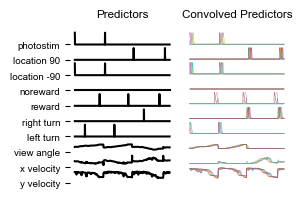

In [ ]:
import scipy
import os
import matplotlib.pyplot as plt
import numpy as np

example_dataset = [mouse_dates_keys[2]]  # e.g., ['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')
model_type = 'pre'
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_{model_type}/'
fold_number = 0

frames = range(6000,6600) #(5990,6150)
path = os.path.join(save_directory, f"prepost trial cv 73 #{fold_number+1}/test")
print(path)

# Load raw behavioral matrix
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix']

behav_ids = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix_ids.mat'))
behav_matrix_ids_raw = behav_ids['behav_the_matrix_ids'][0]

# Load convolved behavioral matrix
behav = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix.mat'))
behav_big_matrix = behav['behav_big_matrix']

behav_big_ids = scipy.io.loadmat(os.path.join(path, 'behav_big_matrix_ids.mat'))
behav_big_matrix_ids = behav_big_ids['behav_big_matrix_ids'][0]

# --- Clean and deduplicate variable names ---
flat_ids = [str(var[0]) if isinstance(var, np.ndarray) else str(var) for var in behav_matrix_ids_raw]
clean_ids = [v.replace('upcoming ', '') for v in flat_ids]

# Deduplicate while preserving order
unique_names = {}
for idx, name in enumerate(clean_ids):
    if name not in unique_names:
        unique_names[name] = idx

deduped_names = list(unique_names.keys())
deduped_indices = list(unique_names.values())

# --- Normalize original behavioral matrix ---
normalized_matrix = np.zeros_like(behav_matrix, dtype=float)
for i in range(behav_matrix.shape[0]):
    row = behav_matrix[i]
    min_val = np.min(row)
    max_val = np.max(row)
    normalized_matrix[i] = (row - min_val) / (max_val - min_val) if max_val - min_val != 0 else 0

# --- Plotting both side-by-side ---
fig, axs = plt.subplots(1, 2, figsize=(3, len(deduped_names) * 0.2), sharex=True)

offset = 1.3

# LEFT: Original normalized variables
for i, idx in enumerate(deduped_indices):
    axs[0].plot(np.array(frames), normalized_matrix[idx, frames] + i * offset, color='black')
axs[0].set_yticks(np.arange(len(deduped_names)) * offset)
axs[0].set_yticklabels(deduped_names, fontsize=7)
axs[0].set_title("Predictors")
# axs[0].set_xlabel("Frame")
# axs[0].set_ylabel("Variables")
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].spines['bottom'].set_visible(False)
axs[0].spines['left'].set_visible(False)
axs[0].set_xticks([])
axs[0].set_xticklabels([])


# RIGHT: Convolved versions (up to 5 per original variable)
for i, name in enumerate(deduped_names):
    matches = [j for j, bigname in enumerate(behav_big_matrix_ids)
               if name in str(bigname[0])]
    print(matches, name)
    for k, idx in enumerate(matches[:5]): #
        axs[1].plot(np.array(frames), behav_big_matrix[idx, frames] + i * offset, alpha=1, linewidth=0.3)
axs[1].set_yticks(np.arange(len(deduped_names)) * offset)
axs[1].set_yticklabels([])  # Remove right subplot yticks
axs[1].set_title("Convolved Predictors")
# axs[1].set_xlabel("Frame")
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].spines['bottom'].set_visible(False)
axs[1].spines['left'].set_visible(False)
axs[1].set_xticks([])
axs[1].set_yticks([])
axs[1].set_xticklabels([])

plt.tight_layout()
plt.savefig(f'{plotter.save_results}/ex_predictors.pdf', bbox_inches='tight')
plt.show()




In [42]:
import scipy
example_dataset =[mouse_dates_keys[0]] #['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')
fold = 0
#find robust neurons based on pre or passive
model_output_all = results_pre[example_dataset[0]]['model_output_all']
model_output_behav = results_pre[example_dataset[0]]['model_output_behav']
# full = model_output_all[fold]
# behav = model_output_behav[fold]
folds = model_output_all.keys()
all_diffs = np.array([
    model_output_all[fold]['frac_dev_expl'] - model_output_behav[fold]['frac_dev_expl']
    for fold in folds
])
mean_diff = np.mean(all_diffs, axis=0)
std_diff = np.std(all_diffs, axis=0)
robust_mask = (mean_diff > 0.1) & (std_diff < 0.05)
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_pre/'
fold_number = 0
path = os.path.join(save_directory, "prepost trial cv 73 #{}/test".format(fold_number+1))
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
#response_matrix[response_matrix > 0.05] = 1 #binarized result
response_matrix = response_matrix[:,:]

corrs = [np.corrcoef(model_output_all[fold]['y_pred'][:, i], response_matrix[i])[0, 1]
         for i in range(response_matrix.shape[0])]

# Handle any NaNs (e.g., if no variance in spike train)
correlations = np.nan_to_num(corrs, nan=0.0)

# Sort neuron indices by correlation (descending)
sorted_corr_indices = np.argsort(correlations)[::-1]
sorted_corr_values = correlations[sorted_corr_indices]

# Print top 10 for inspection
for i in range(10):
    print(f"Neuron {sorted_corr_indices[i]} | Corr: {sorted_corr_values[i]:.3f}")

print(np.where(robust_mask))

Neuron 256 | Corr: 0.600
Neuron 268 | Corr: 0.436
Neuron 48 | Corr: 0.401
Neuron 278 | Corr: 0.398
Neuron 199 | Corr: 0.391
Neuron 330 | Corr: 0.391
Neuron 103 | Corr: 0.354
Neuron 340 | Corr: 0.334
Neuron 338 | Corr: 0.332
Neuron 89 | Corr: 0.328
(array([  7,  43,  59,  68,  72, 103, 172, 288, 366, 371], dtype=int64),)


V:/Connie/ProcessedData/HA2-1L/2023-04-12/GLM_3nmf_pre/prepost trial cv 73 #5/test
(377, 12563)
Plotting neurons: [ 3 38]


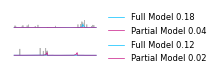

Plotting neurons: [ 3 38]


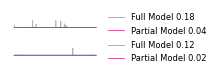

Plotting neurons: [ 3 38]


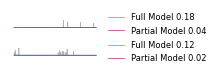

In [121]:
# PLOT EXAMPLE NEURON PREDICTIONS VS TRUE DATA FOR BOTH MODELS FOR FOLD 1
import scipy
import os
import matplotlib.pyplot as plt
import numpy as np
example_dataset =[mouse_dates_keys[2]] #['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')

supp_figure_dir = f'{save_results}/glm_coupling/supplemental'
os.makedirs(supp_figure_dir, exist_ok=True)

#find robust neurons based on pre or passive

fold_number = 4
model_type = 'pre'

save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_{model_type}/'
if model_type == 'pre':
    model_output_all = results_pre[example_dataset[0]]['model_output_all']
    model_output_behav = results_pre[example_dataset[0]]['model_output_behav']
else:
    model_output_all = results_pass[example_dataset[0]]['model_output_all']
    model_output_behav = results_pass[example_dataset[0]]['model_output_behav']
#find neurons based on pre
frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
frac_dev_expl_behav = model_output_behav[fold_number]['frac_dev_expl']

# 1️⃣ Set thresholds
min_diff = 0.1         # minimum difference between full and behav model
min_frac_expl = 0.1     # minimum overall fraction explained
min_behav_frac = 0.0    # minimum fraction explained for behavior-only model

# 2️⃣ Mask neurons that satisfy all criteria
mask = (frac_dev_expl_diff >= min_diff) & \
    (frac_dev_expl >= min_frac_expl) & \
    (frac_dev_expl_behav > min_behav_frac)

path = os.path.join(save_directory, "prepost trial cv 73 #{}/test".format(fold_number+1))
print(path)
# Load actual response data
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
#response_matrix[response_matrix > 0.05] = 1 #binarized result
response_matrix = response_matrix[:,:]
print(response_matrix.shape)

corrs = [np.corrcoef(model_output_all[fold_number]['y_pred'][:, i], response_matrix[i])[0, 1]
        for i in range(response_matrix.shape[0])]

# Handle any NaNs (e.g., if no variance in spike train)
correlations = np.nan_to_num(corrs, nan=0.0)

# Sort neuron indices by correlation (descending)
sorted_corr_indices = np.argsort(correlations)[::-1]
sorted_corr_values = correlations[sorted_corr_indices]
robust_mask = (frac_dev_expl_diff > 0.05) & (correlations > 0.3)

# 3️⃣ Get indices of top neurons (sorted by frac_dev_expl within mask)
top_indices = np.argsort(frac_dev_expl[robust_mask])[::-1]

# 4️⃣ Map back to original indices
selected_neurons = np.where(mask)[0][top_indices]
sorted_indices = selected_neurons

#load behav matrix to have some sort of trial structure
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix'] #7/8 are sounds

# Example neuron IDs to plot (replace with your specific neuron IDs)
# neuronIDs = np.random.choice(response_matrix.shape[0],4, replace = False)#[0, 1, 2, 3]  # Example list of neuron IDs
# Sort neuron IDs based on frac_dev_expl (descending)
# frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# sorted_indices = np.argsort(frac_dev_expl_diff)[::-1]  # descending order
neuronIDs = sorted_indices[:2]  # Take top 4 [:4]
ranges = [range(i, i+500) for i in range(0, 3000, 1000)]
for frames in ranges: #[range(0,2000), range(2000,4000), range(4000,6000), range(6000,8000)]: #ranges: #
    print("Plotting neurons:", neuronIDs)
    # Create subplots for each neuron
    fig, axs = plt.subplots(len(neuronIDs), 1, figsize=(2.3,.7), sharex=True) #(4,3)
    # Plot each neuron's y_pred for both models
    for i, neuronID in enumerate(neuronIDs):
        # Extract y_pred data for neuronID from model_output_all and model_output_behav
        real_y = response_matrix[neuronID,frames] #
        y_pred_model1 = model_output_all[fold_number]['y_pred'][frames, neuronID]
        y_pred_model_behav = model_output_behav[fold_number]['y_pred'][frames, neuronID]
        # Plot y_pred for neuronID from both models in the i-th subplot
        # axs[i].plot(behav_matrix[7,frames],color = [0.9, 0.9, 0.9 ] , label='Sound Onset 1')
        # axs[i].plot(behav_matrix[8,frames],color = [0.8, 0.8, 0.8 ] , label='Sound Onset 2')
        axs[i].plot(real_y,color = [0.7, 0.7, 0.7 ] , linewidth=.5) #, label='Deconvolved'
        axs[i].plot(y_pred_model1, label=f"Full Model {model_output_all[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['full'] , linewidth=.5) #[0.4, 0.4, 1 ]
        axs[i].plot(y_pred_model_behav,label=f"Partial Model {model_output_behav[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['behav'], linewidth=.5) #[0.8, 0.5, 1]
        # Set title and labels for the subplot
        # axs[i].set_title(f'Neuron {neuronID} ') # Comparison between Coupling and no Coupling Model
        # axs[i].set_xlabel('Frames')
        axs[i].set_ylabel('Prediction Value')

        # remove box for each subplot
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
        # axs[i].spines['bottom'].set_visible(False)
        # axs[i].spines['left'].set_visible(False)
        axs[i].axis('off')
        # Add legend to the subplot
        axs[i].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)
    # Adjust layout and display
    plt.tight_layout()
    os.chdir(supp_figure_dir)
    plt.savefig(f'ex_neurons_{neuronIDs}_{animalID}_{date}_{model_type}_fold{fold_number}_{frames[0]}to{frames[-1]}.pdf')
    plt.show()

In [ ]:
plt.plot(variables[''])

V:/Connie/ProcessedData/HA2-1L/2023-04-12/GLM_3nmf_passive/prepost trial cv 73 #5/test
(377, 5249)


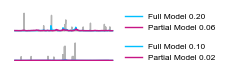

In [267]:
# PLOT EXAMPLE NEURON PREDICTIONS VS TRUE DATA FOR BOTH MODELS FOR FOLD 1
import scipy
example_dataset =[mouse_dates_keys[2]] #['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')

fold_number = 4
model_type = 'pass'
if model_type == 'pre':
    save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_pre/'
    model_output_all = results_pre[example_dataset[0]]['model_output_all']
    model_output_behav = results_pre[example_dataset[0]]['model_output_behav']
    #find neurons based on pre
    frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
    frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
    sorted_indices = [350,201] #np.argsort(frac_dev_expl_diff)[::-1]  # descending order
else:
    save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_passive/'
    model_output_all = results_pass[example_dataset[0]]['model_output_all']
    model_output_behav = results_pass[example_dataset[0]]['model_output_behav']


frames = range(1500,2000) #range(0,3000) #range(0,600) #range(0,3000)#range(0,600)
path = os.path.join(save_directory, "prepost trial cv 73 #{}/test".format(fold_number+1))
print(path)
# Load actual response data
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
#response_matrix[response_matrix > 0.05] = 1 #binarized result
response_matrix = response_matrix[:,:]
print(response_matrix.shape)
#load behav matrix to have some sort of trial structure
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix'] #7/8 are sounds

# Example neuron IDs to plot (replace with your specific neuron IDs)
# neuronIDs = np.random.choice(response_matrix.shape[0],4, replace = False)#[0, 1, 2, 3]  # Example list of neuron IDs
# Sort neuron IDs based on frac_dev_expl (descending)
# frac_dev_expl = model_output_all[fold_number]['frac_dev_expl']
# frac_dev_expl_diff = model_output_all[fold_number]['frac_dev_expl'] - model_output_behav[fold_number]['frac_dev_expl']
# sorted_indices = np.argsort(frac_dev_expl_diff)[::-1]  # descending order
neuronIDs = sorted_indices[:2]  # Take top 4 [:4]

# Create subplots for each neuron
fig, axs = plt.subplots(len(neuronIDs), 1, figsize=(2.3,.7), sharex=True) #(4,3)
# Plot each neuron's y_pred for both models
for i, neuronID in enumerate(neuronIDs):
    # Extract y_pred data for neuronID from model_output_all and model_output_behav
    real_y = response_matrix[neuronID,frames] #
    y_pred_model1 = model_output_all[fold_number]['y_pred'][frames, neuronID]
    y_pred_model_behav = model_output_behav[fold_number]['y_pred'][frames, neuronID]
    # Plot y_pred for neuronID from both models in the i-th subplot
    # axs[i].plot(behav_matrix[7,frames],color = [0.9, 0.9, 0.9 ] , label='Sound Onset 1')
    # axs[i].plot(behav_matrix[8,frames],color = [0.8, 0.8, 0.8 ] , label='Sound Onset 2')
    axs[i].plot(real_y,color = [0.7, 0.7, 0.7 ] , linewidth=1) #, label='Deconvolved'
    axs[i].plot(y_pred_model1, label=f"Full Model {model_output_all[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['full'] , linewidth=1) #[0.4, 0.4, 1 ]
    axs[i].plot(y_pred_model_behav,label=f"Partial Model {model_output_behav[fold_number]['frac_dev_expl'][neuronID]:.2f}",color = plotter.default_colors_model_type['behav'], linewidth=1) #[0.8, 0.5, 1]
    # Set title and labels for the subplot
    # axs[i].set_title(f'Neuron {neuronID} ') # Comparison between Coupling and no Coupling Model
    # axs[i].set_xlabel('Frames')
    axs[i].set_ylabel('Prediction Value')

    # remove box for each subplot
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    # axs[i].spines['bottom'].set_visible(False)
    # axs[i].spines['left'].set_visible(False)
    axs[i].axis('off')
    # Add legend to the subplot
    axs[i].legend(frameon=False, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=6)
# Adjust layout and display
plt.tight_layout()
os.chdir(supp_figure_dir)
plt.savefig(f'ex_neurons_{neuronIDs}_'+animalID+'_'+date+'_'+model_type+'.pdf')
plt.show()

In [303]:
sorted_indices

array([283, 159, 148,   2, 156,  52, 312,   3, 187,  11, 131,  88, 173,
       332, 122,  38, 295,  46, 101, 177, 262,   0,   9,   5,  27,  80,
       376, 365, 371, 150,  81,  55, 246, 357, 355,  31, 209, 107,  40,
        20,  77, 311, 221, 189, 138, 100, 358, 324,   6, 370,  92, 115,
       118, 103, 186,  74, 363, 280, 123, 257,  62, 322,  79, 341, 217,
       145,  48, 366, 302, 132, 372, 310, 281, 237, 119, 213, 356, 208,
        36, 291,  86, 220, 198,  84, 105,   8, 255, 219, 303, 293, 120,
        47,  35,  41, 117, 212, 210, 193,  99, 130, 143,  89, 359, 294,
        34, 167,  29, 194,  16,  50, 154, 160, 259,  10,  73, 297,  51,
        69, 287,  15, 196,  12, 333, 373, 306, 354, 315,   1, 277,  44,
        39, 110,  53, 342, 121, 321, 111,   7, 231,  67, 141, 351,  90,
        32, 183, 203, 201, 218, 328, 228, 179,  58, 188, 265,  23, 112,
       195, 319, 192, 144, 133,  76,  14, 104, 243, 367, 184, 233, 276,
       190, 374,  30,  43, 216, 335, 180, 339, 272, 137,  19, 36

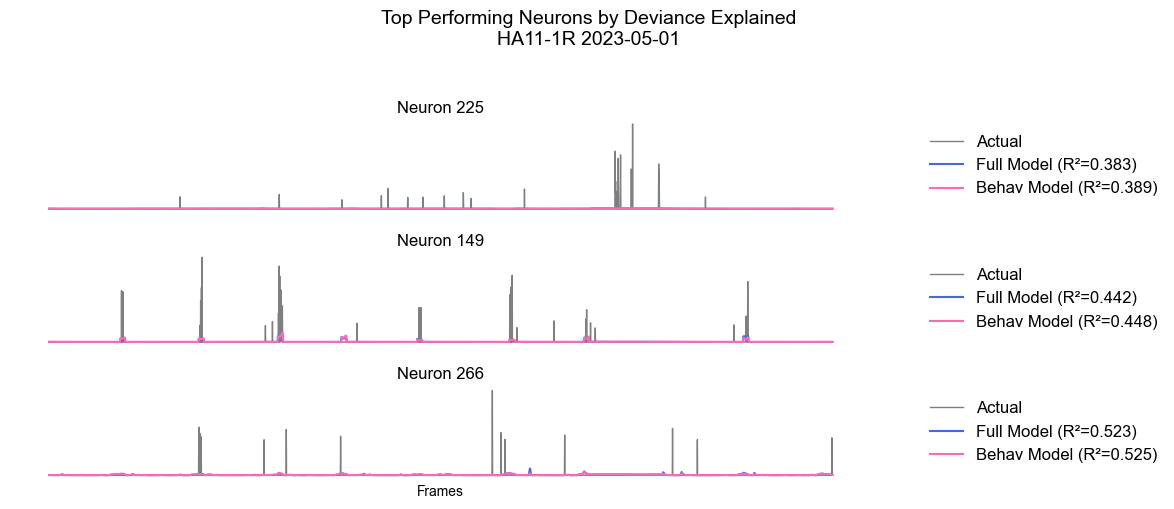


Plotted neurons summary:
Neuron 225: Full Model R² = 0.383, Behav Model R² = 0.389
Neuron 149: Full Model R² = 0.442, Behav Model R² = 0.448
Neuron 266: Full Model R² = 0.523, Behav Model R² = 0.525


In [116]:
# PLOT TOP PERFORMING NEURONS BY DEVIANCE EXPLAINED
import scipy
example_dataset = ['HA11-1R_2023-05-01']
animalID, date = example_dataset[0].split('_')
model_type = 'pre'
save_directory = f'V:/Connie/ProcessedData/{animalID}/{date}/GLM_3nmf_{model_type}/'
fold_number = 0
model_output_all = results_pre[example_dataset[0]]['model_output_all']
model_output_behav = results_pre[example_dataset[0]]['model_output_behav']

# Get deviance explained values and find top neurons
dev_expl_all = model_output_all[fold_number]['frac_dev_expl']
dev_expl_behav = model_output_behav[fold_number]['frac_dev_expl']

# Clean deviance values to remove outliers
def clean_dev_values(dev_values, lower_bound=-1, upper_bound=1):
    cleaned_dev = np.array(dev_values, dtype=float)
    cleaned_dev[(cleaned_dev < lower_bound) | (cleaned_dev > upper_bound)] = np.nan
    return cleaned_dev

dev_expl_all_clean = clean_dev_values(dev_expl_all)
# Get indices of top 4 neurons by deviance explained
# neuronIDs = np.argsort(dev_expl_all_clean)[-3:]
# Get indices of top 3 neurons by deviance explained, excluding NaN values
valid_neurons = ~np.isnan(dev_expl_all_clean)
neuronIDs = np.argsort(dev_expl_all_clean[valid_neurons])[-3:]
neuronIDs = np.arange(len(dev_expl_all_clean))[valid_neurons][neuronIDs]


# Load and prepare data
frames = range(0,3000)
path = os.path.join(save_directory, "prepost trial cv 73 #{}/test".format(fold_number+1))
response = scipy.io.loadmat(os.path.join(path, 'combined_response.mat'))
response_matrix = response['combined_response']
behav = scipy.io.loadmat(os.path.join(path, 'behav_the_matrix.mat'))
behav_matrix = behav['behav_the_matrix']

# Create subplots for each neuron
fig, axs = plt.subplots(len(neuronIDs), 1, figsize=(12, 5), sharex=True)

# Plot each top neuron
for i, neuronID in enumerate(neuronIDs):
    real_y = response_matrix[neuronID,frames]
    y_pred_model1 = model_output_all[fold_number]['y_pred'][frames, neuronID]
    y_pred_model_behav = model_output_behav[fold_number]['y_pred'][frames, neuronID]
    
    # Plot with enhanced styling
    # axs[i].plot(behav_matrix[7,frames], color='lightgray', alpha=0.3, label='Sound 1')
    # axs[i].plot(behav_matrix[8,frames], color='darkgray', alpha=0.3, label='Sound 2')
    axs[i].plot(real_y, color='black', alpha=0.5, label='Actual', linewidth=1)
    axs[i].plot(y_pred_model1, 
                label=f"Full Model (R²={dev_expl_all_clean[neuronID]:.3f})", 
                color='royalblue', 
                linewidth=1.5)
    axs[i].plot(y_pred_model_behav,
                label=f"Behav Model (R²={dev_expl_behav[neuronID]:.3f})", 
                color= 'hotpink', #'mediumpurple'
                linewidth=1.5)
    
    # Enhance subplot appearance
    axs[i].set_title(f'Neuron {neuronID}', fontsize=12, pad=5)
    axs[i].set_ylabel('Activity (a.u.)', fontsize=10)
    axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, frameon='false',edgecolor = 'white')
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].spines['bottom'].set_visible(False)
    axs[i].spines['left'].set_visible(False)

    # Remove x and y axis labels
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')

    # Remove x and y ticks
    axs[i].set_xticks([])
    axs[i].set_yticks([])

    # Optional: also remove the tick labels (just to be sure)
    axs[i].set_xticklabels([])
    axs[i].set_yticklabels([])
    # axs[i].grid(True, alpha=0.2)

# Add common xlabel
axs[-1].set_xlabel('Frames', fontsize=10)

# Add overall title
fig.suptitle(f'Top Performing Neurons by Deviance Explained\n{animalID} {date}', 
             fontsize=14, y=1.02)

# Adjust layout and save
plt.tight_layout()
save_path = os.path.join(save_results, f'top_neurons_dev_expl_{animalID}_{date}_{model_type}.pdf')
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

# Print summary of plotted neurons
print("\nPlotted neurons summary:")
for neuronID in neuronIDs:
    print(f"Neuron {neuronID}: Full Model R² = {dev_expl_all_clean[neuronID]:.3f}, "
          f"Behav Model R² = {dev_expl_behav[neuronID]:.3f}")

In [101]:
save_path

'V:/Connie/results/glm/2025/updated\\top_neurons_dev_expl_HA11-1R_2023-05-05_passive.pdf'

In [50]:
# Import local utilities
from utils.dataset_processor import DatasetProcessor
from utils.cell_visualizer import CellVisualizer
# Load data from States_pupil_analysis
from helper_functions.data_pipeline import DataPipeline
pipeline = DataPipeline()
data_loaders, celltype_info = pipeline.load_data(datasets=datasets, load_celltypes=True)

# Initialize processor with alignment parameters
processor = DatasetProcessor(alignment={
    'type': 'pre',
    'data_type': 'z_dff'
})

fields_to_separate = ['condition'] #is_stim_trial, correct, condition left_turn,
# 
# Create trial divider for condition splitting
trial_divider = TrialDivider()

# Process and align all datasets
aligned_data = processor.process_datasets(
    data_loaders=data_loaders,
    celltype_info=celltype_info,
    save_string = 'passive',
    save_path='aligned_data_passive.pkl'
)

# For each dataset, create condition splits
for (animalID, date), data in aligned_data.items():
    print(f"\nProcessing {animalID} {date}")
    
    # Create condition splits
    
    all_conditions, condition_array = trial_divider.divide_trials_from_df(
        trial_info_df=data['trial_info'],
        good_trials=data['good_trials'],
        fields_to_separate=fields_to_separate
    )
    
    # Store conditions in aligned_data for later use
    aligned_data[(animalID, date)]['all_conditions'] = all_conditions
    print(f"Found {len(all_conditions)} conditions")

# Verify alignment worked
for (animalID, date), data in aligned_data.items():
    print(f"\nDataset: {animalID} {date}")
    print(f"Aligned imaging shape: {data['aligned_imaging'].shape}")
    print(f"Number of good trials: {len(data['good_trials'])}")
    print(f"Number of conditions: {len(data['all_conditions'])}")

Loading data for: Animal: HA11-1R, Date: 2023-05-05, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-04-13, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-04-12, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-05-05, Server: V:
Loading data for: Animal: HA1-00, Date: 2023-06-29, Server: V:
Loading data for: Animal: HA1-00, Date: 2023-08-28, Server: W:
Loading data for: Animal: HE4-1L1R, Date: 2023-08-21, Server: W:
Loading data for: Animal: HE4-1L1R, Date: 2023-08-24, Server: W:
Loading data for: Animal: HA10-1L, Date: 2023-04-10, Server: V:
Loading data for: Animal: HA10-1L, Date: 2023-04-17, Server: V:
Loading data for: Animal: HA10-1L, Date: 2023-04-12, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-04-07, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-05-01, Server: V:
Loading data for: Animal: HA11-1R, Date: 2023-05-02, Server: V:
Loading data for: Animal: HA2-1L, Date: 2023-04-28, Server: V:
Loading data for: Animal: HA2-1L, Date: 202

TypeError: DatasetProcessor.process_datasets() got an unexpected keyword argument 'save_string'